In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
import re
import numpy as np

headers = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "en-US,en;q=0.9"
}

city_areas = {
    "kochi":['edappally', 'panampilly-nagar', 'kacheripady', 'vyttila',  'fort-kochi', 'palarivattom', 'kakkanad', 'mg-road'],
    "bangalore": ["indiranagar", "whitefield", "koramangala", "btm", "hsr"],
    "chennai": ["t-nagar", "velachery", "adyar", "porur", "nungambakkam"],
    "varanasi": ['lanka', 'sigra', 'bhelupur',  'assi-ghat', 'chetganj', 'nadesar', 'dashaswmedh-road', 'mahmoorganj'],
    "trivandrum": ['kannanthura', 'kazhakkoottam', 'ambalamukku', 'kesavadasapuram', 'kumarapuram', 'palayam', 'thycaud', 'kulathoor'],
    "thrissur": ['poothole', 'ayyanthole', 'guruvayur-locality', 'chalakudy', 'irinjalakuda-locality', 'peringavu', 'kizhakkumpattukara', 'puzhakkal'],
    "pune": ['kothrud', 'wakad', 'hinjawadi', 'kalyani-nagar', 'kharadi','viman-nagar'],
    "puducherry": ['auroville', 'gandhinagar', 'mudaliarpet', 'kottukuppam', 'heritage-town', 'lawspet', 'white-town', 'mg-road'],
    "ooty":['anna-nagar', 'kandal', 'marlimund', 'elk-hill', 'fern-hill', 'thalayathimund'],
    "mysore": ['vijay-nagar', 'chamrajpura', 'doora', 'mandi-mohalla', 'jayalakhsmipuram', 'bannimantap', 'kuvempunagar', 'gokulam'],
    "manali": ['old-manali','aleo', 'tibetan-colony'],
    "mangalore": ['lalbagh', 'balmatta', 'kodailbail', 'hampankatta', 'kadri', 'ks-rao-nagar',  'kankanady', 'attavar'],
    "madurai": ['kk-nagar', 'arrapalayam', 'iyer-bungalow', 'viswanathapuram', 'periyar', 'othakadai', 'ss-colony', 'sathamangalam'],
    "lucknow": ['gomti-nagar', 'hazratganj', 'aliganj', 'aashiana', 'aminabad', 'indira-nagar', 'alambagh', 'chowk'],
    "kolkata": ['park-street-area', 'sector-1-salt-lake', 'ballygunge', 'camac-street-area', 'southern-avenue', 'new-town', 'sector-5-salt-lake', 'chinar-park'],
    "goa": ['calangute', 'margao', 'vagator', 'panaji', 'arambol', 'anjuna', 'baga', 'candolim'],
    "delhi": ['connaught-place-delhi', 'rajouri-garden-delhi', 'sector-18-noida', 'golf-course-road', 'dlf-cyber-city',  'sector-29-gurgaon-gurugram', 'saket-delhi', 'dlf-phase-4'],
    "coimbatore": ['ramanathapuram', 'town-hall', 'kalapatti', 'peelamedu',  'rs-puram', 'saibaba-colony', 'gandhipuram', 'race-course'],
    "chennai": ['thuraipakkam', 'mylapore', 'alwarpet', 't-nagar', 'adyar', 'velachery', 'nungambakkam', 'anna-nagar-east'],
    "amritsar": ['town-hall', 'basant-nagar',  'ina-colony',  'lawrence-road', 'white-avenue', 'gt-road', 'kabir-park', 'ranjit-avenue'],
    "agra": ['rakabganj', 'khandari', 'tajganj', 'kamla-nagar', 'agra-cantt', 'sikandra', 'civil-lines', 'mantola'],
    "jamshedpur": ['telco-colony', 'golmuri', 'sakchi', 'bistupur', 'gamharia', 'sonari', 'mango', 'birsanagar']

}

data = []

# -----------------------------
# WIKIPEDIA
# -----------------------------
def get_wiki(city):
    try:
        url = f"https://en.wikipedia.org/wiki/{city.capitalize()}"
        res = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(res.text, "lxml")
        text = soup.get_text()

        pop = re.search(r'Population.*?(\d{1,3}(?:,\d{3})+)', text)
        area = re.search(r'Area.*?(\d{1,3}(?:,\d{3})*)\s?km', text)

        return (
            pop.group(1) if pop else None,
            area.group(1) if area else None,
            "yes" if "tourism" in text.lower() else "no",
            "yes" if "gdp" in text.lower() else "no"
        )
    except:
        return None, None, None, None


# -----------------------------
# MAIN SCRAPER
# -----------------------------
for city in city_areas:

    print(f"\nCITY: {city}")
    pop, area_km, tourism_flag, gdp_flag = get_wiki(city)

    for area in city_areas[city]:

        for page in range(1, 11):

            url = f"https://www.zomato.com/{city}/{area}-restaurants?page={page}"
            print(f"{city}-{area} Page {page} | Rows: {len(data)}")

            try:
                res = requests.get(url, headers=headers, timeout=10)

                if res.status_code != 200:
                    break

                soup = BeautifulSoup(res.text, "lxml")
                cards = soup.find_all("div", class_="jumbo-tracker")

                if not cards:
                    break

                for card in cards:
                    try:
                        name = card.find("h4")
                        name = name.text.strip() if name else None

                        cuisine = card.find("p")
                        cuisine = cuisine.text.strip() if cuisine else "Unknown"

                        # Cuisine count
                        cuisine_count = len(cuisine.split(",")) if cuisine else 0

                        # Price
                        price_tag = card.find(string=lambda t: t and "₹" in t)
                        price_text = price_tag.strip() if price_tag else None

                        cost = None
                        if price_text:
                            m = re.search(r'\d+', price_text.replace(',', ''))
                            if m:
                                cost = int(m.group())

                        # Price category
                        if cost:
                            if cost < 200:
                                price_category = "low"
                            elif cost < 500:
                                price_category = "medium"
                            else:
                                price_category = "high"
                        else:
                            price_category = None

                        # Rating
                        rating_tag = card.find(string=lambda x: x and re.match(r'^\d\.\d$', x))
                        rating = float(rating_tag) if rating_tag else None

                        # Rating category
                        if rating:
                            if rating >= 4:
                                rating_category = "excellent"
                            elif rating >= 3:
                                rating_category = "good"
                            else:
                                rating_category = "poor"
                        else:
                            rating_category = None

                        # Links & image
                        link_tag = card.find("a", href=True)
                        link = "https://www.zomato.com" + link_tag['href'] if link_tag else None

                        img_tag = card.find("img")
                        image = img_tag['src'] if img_tag else None

                        text_blob = card.get_text().lower()

                        # Type
                        restaurant_type = "quick_bite" if "quick" in text_blob else "casual"

                        # Features
                        order_online = "yes" if "order online" in text_blob else "no"
                        book_table = "yes" if "book a table" in text_blob else "no"
                        delivery_available = 1 if "delivery" in text_blob else 0
                        dinein_available = 1 if "dine" in text_blob else 0

                        if name:
                            data.append([
                                name, cuisine, cuisine_count,
                                cost, price_category,
                                rating, rating_category,
                                order_online, book_table,
                                delivery_available, dinein_available,
                                restaurant_type,
                                city, area,
                                pop, area_km,
                                tourism_flag, gdp_flag,
                                link, image
                            ])

                    except:
                        continue

                time.sleep(random.uniform(1, 2))

            except:
                break


# -----------------------------
# DATAFRAME
# -----------------------------
columns = [
    "name","cuisine","cuisine_count",
    "cost","price_category",
    "rating","rating_category",
    "order_online","book_table",
    "delivery_available","dinein_available",
    "restaurant_type",
    "city","area",
    "city_population","city_area_km",
    "tourism_flag","gdp_flag",
    "link","image"
]

df = pd.DataFrame(data, columns=columns)
df.to_csv("final_perfect_dataset.csv", index=False)

if df.empty:
    print("❌ No data scraped")
else:
    df.drop_duplicates(inplace=True)

print("\n✅ FINAL PERFECT DATASET CREATED")
print("Rows:", len(df))


CITY: kochi
kochi-edappally Page 1 | Rows: 0
kochi-edappally Page 2 | Rows: 9
kochi-edappally Page 3 | Rows: 18
kochi-edappally Page 4 | Rows: 27
kochi-edappally Page 5 | Rows: 36
kochi-edappally Page 6 | Rows: 45
kochi-edappally Page 7 | Rows: 54
kochi-edappally Page 8 | Rows: 63
kochi-edappally Page 9 | Rows: 72
kochi-edappally Page 10 | Rows: 81
kochi-panampilly-nagar Page 1 | Rows: 90
kochi-panampilly-nagar Page 2 | Rows: 99
kochi-panampilly-nagar Page 3 | Rows: 108
kochi-panampilly-nagar Page 4 | Rows: 117
kochi-panampilly-nagar Page 5 | Rows: 126
kochi-panampilly-nagar Page 6 | Rows: 135
kochi-panampilly-nagar Page 7 | Rows: 144
kochi-panampilly-nagar Page 8 | Rows: 153
kochi-panampilly-nagar Page 9 | Rows: 162
kochi-panampilly-nagar Page 10 | Rows: 171
kochi-kacheripady Page 1 | Rows: 180
kochi-kacheripady Page 2 | Rows: 189
kochi-kacheripady Page 3 | Rows: 198
kochi-kacheripady Page 4 | Rows: 207
kochi-kacheripady Page 5 | Rows: 216
kochi-kacheripady Page 6 | Rows: 225
kochi-k

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/final_dataset.csv")

##Data Analysis

In [ ]:
df.shape

(13185, 20)

In [ ]:
df.head()

,name,cuisine,cuisine_count,cost,price_category,rating,rating_category,order_online,book_table,delivery_available,dinein_available,restaurant_type,city,area,city_population,city_area_km,tourism_flag,gdp_flag,link,image
0,Kubaba,"Biryani, Mandi, Arabian",3,1000.0,high,4.4,excellent,Yes,Yes,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/kubaba-edappally/...,NaN
1,Kochi Kitchen - Kochi Marriott Hotel,"South Indian, Asian, North Indian, Continental...",6,2500.0,high,4.6,excellent,Yes,Yes,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/kochi-kitchen-koc...,NaN
2,Fress Trees Garden Cafe,"Continental, Pizza, Beverages, Asian, Burger, ...",6,600.0,high,4.5,excellent,Yes,No,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/fress-trees-garde...,NaN
3,Yaacht Kitchen,"Kerala, South Indian, Continental, Oriental, A...",8,1500.0,high,4.2,excellent,Yes,No,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/yaacht-kitchen-er...,NaN
4,Punjab Grill,"North Indian, Kebab, Biryani, Mughlai",4,1700.0,high,4.4,excellent,No,Yes,1,1,casual,kochi,edappally,"677,381",88,yes,yes,https://www.zomato.com/kochi/punjab-grill-edap...,NaN


In [ ]:
df.tail()

,name,cuisine,cuisine_count,cost,price_category,rating,rating_category,order_online,book_table,delivery_available,dinein_available,restaurant_type,city,area,city_population,city_area_km,tourism_flag,gdp_flag,link,image
13180,New Facilities,"North Indian, Street Food",2,250.0,medium,3.9,good,Yes,Yes,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/new-faciliti...,NaN
13181,Pizza Hut,"Pizza, Fast Food, Desserts, Beverages",4,300.0,medium,4.1,excellent,No,No,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/pizza-hut-sa...,NaN
13182,Haridra - By DeHamray,"North Indian, Italian, Japanese, Continental, ...",8,1500.0,high,4.7,excellent,Yes,Yes,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/haridra-by-d...,NaN
13183,Hasapi,"Continental, North Indian, Chinese, Sushi, Sea...",6,1000.0,high,4.5,excellent,No,Yes,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/hasapi-sakch...,NaN
13184,Kadhi Patta - Pure Veg Restaurant,"North Indian, South Indian",2,800.0,high,4.5,excellent,No,No,1,1,casual,jamshedpur,birsanagar,"629,659",224,yes,no,https://www.zomato.com/jamshedpur/kadhi-patta-...,NaN


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(5059, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5059 entries, 0 to 13180
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                5059 non-null   object 
 1   cuisine             4976 non-null   object 
 2   cuisine_count       5059 non-null   int64  
 3   cost                5057 non-null   float64
 4   price_category      5057 non-null   object 
 5   rating              4518 non-null   float64
 6   rating_category     4518 non-null   object 
 7   order_online        5059 non-null   object 
 8   book_table          5059 non-null   object 
 9   delivery_available  5059 non-null   int64  
 10  dinein_available    5059 non-null   int64  
 11  restaurant_type     5059 non-null   object 
 12  city                5059 non-null   object 
 13  area                5059 non-null   object 
 14  city_population     4680 non-null   object 
 15  city_area_km        4680 non-null   object 
 16  tourism_fl

In [ ]:
df.columns

Index(['name', 'cuisine', 'cuisine_count', 'cost', 'price_category', 'rating',
       'rating_category', 'order_online', 'book_table', 'delivery_available',
       'dinein_available', 'restaurant_type', 'city', 'area',
       'city_population', 'city_area_km', 'tourism_flag', 'gdp_flag', 'link',
       'image'],
      dtype='object')

In [ ]:
df.describe()

,cuisine_count,cost,rating,delivery_available,dinein_available,image
count,5059.000000,5057.000000,4518.000000,5059.000000,5059.000000,0.0
mean,5.246689,1308.315207,4.312793,0.999209,0.999209,NaN
std,2.314281,728.897187,0.337954,0.028111,0.028111,NaN
min,0.000000,150.000000,3.000000,0.000000,0.000000,NaN
25%,3.000000,800.000000,4.100000,1.000000,1.000000,NaN
50%,5.000000,1200.000000,4.400000,1.000000,1.000000,NaN
75%,8.000000,1700.000000,4.500000,1.000000,1.000000,NaN
max,8.000000,6000.000000,4.900000,1.000000,1.000000,NaN


In [ ]:
df.dtypes

,0
name,object
cuisine,object
cuisine_count,int64
cost,float64
price_category,object
rating,float64
rating_category,object
order_online,object
book_table,object
delivery_available,int64


In [ ]:
df['rating'].value_counts() #target

,count
rating,
4.4,685
4.5,633
4.3,603
4.1,511
4.2,444
4.6,384
4.9,231
4.7,213
4.0,163


In [ ]:
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: name
name
Barbeque Nation                  54
Pind Balluchi                    42
Chinese Wok                      37
The Vibe                         33
Chicking                         33
                                 ..
O2 cafe & dining                  1
Pandit Bhojanalya                 1
Mom & Mirchi                      1
Berco's - If You Love Chinese     1
Jetty                             1
Name: count, Length: 549, dtype: int64

Column: cuisine
cuisine
NaN                                                                              83
Chinese                                                                          72
North Indian, BBQ, Kebab, Biryani                                                50
Mandi, Arabian                                                                   39
Arabian, Biryani, Chinese, Mandi, South Indian, North Indian, Shake, Desserts    35
                                                                                 ..
North Indian, Chi

In [ ]:
df.drop(columns=["image"], inplace=True) # many null values

In [ ]:
#df.drop(columns=["name","link","rating_category","area","restaurant_type","image"], inplace = True)

## Data Visualization

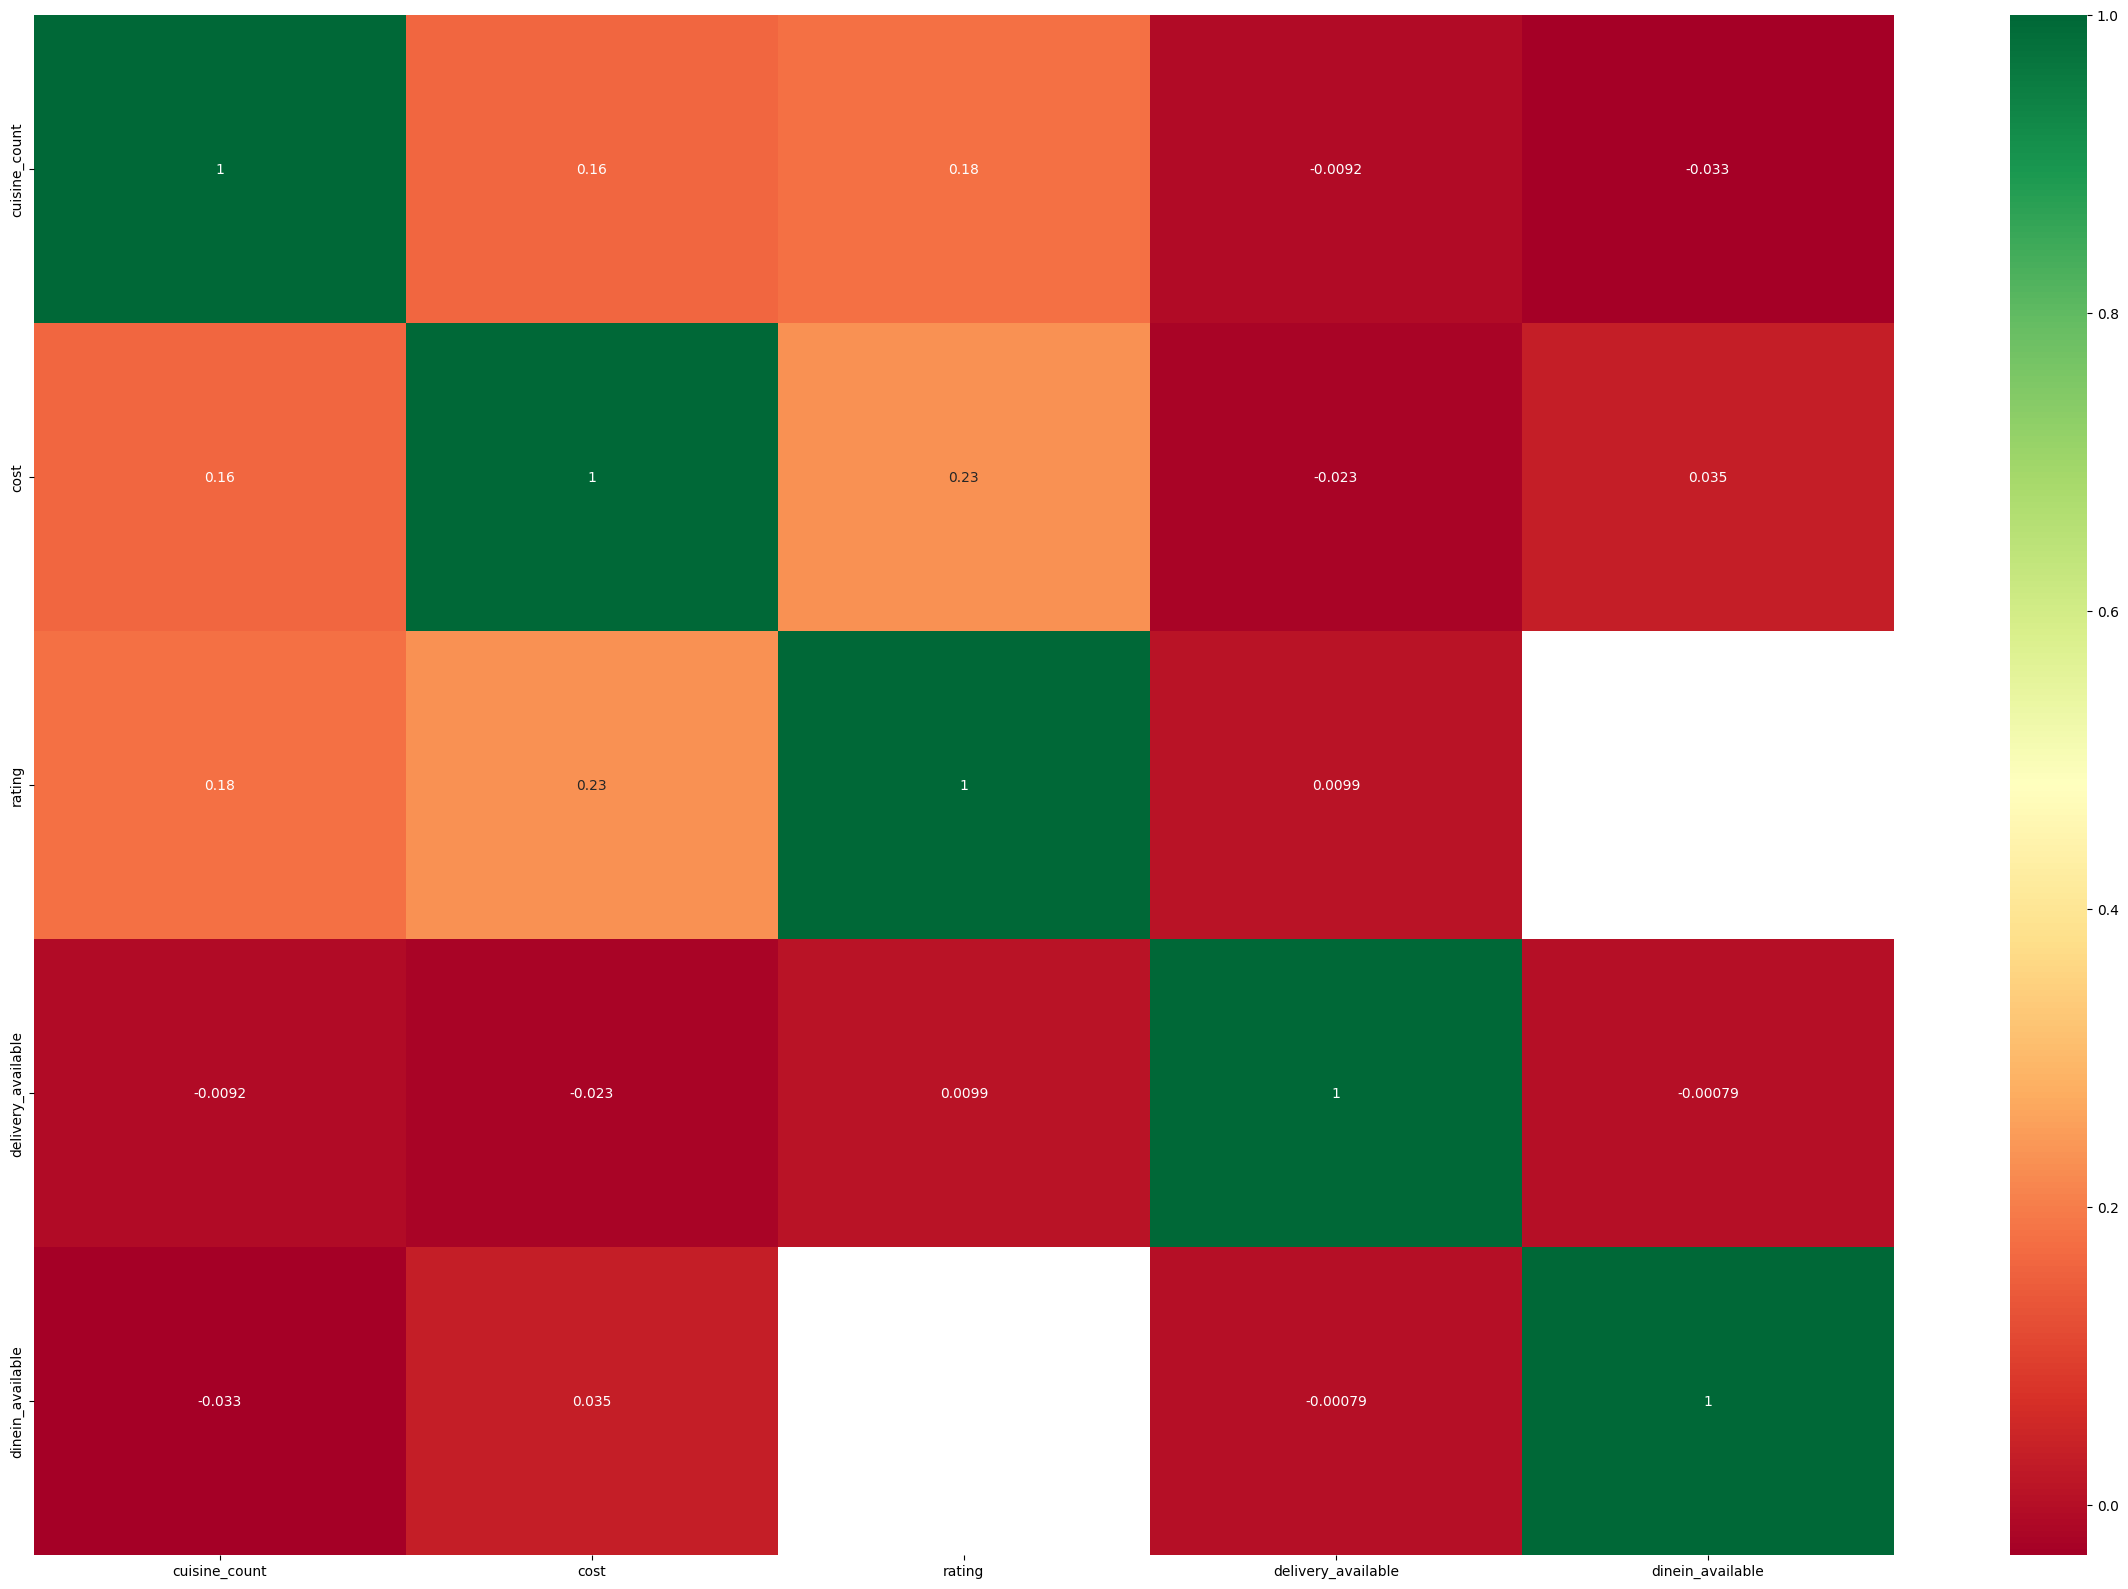

In [ ]:
corrmap = df.select_dtypes(include='number').corr()
plt.figure(figsize=(30,20))
sns.heatmap(corrmap, annot=True, cmap="RdYlGn")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

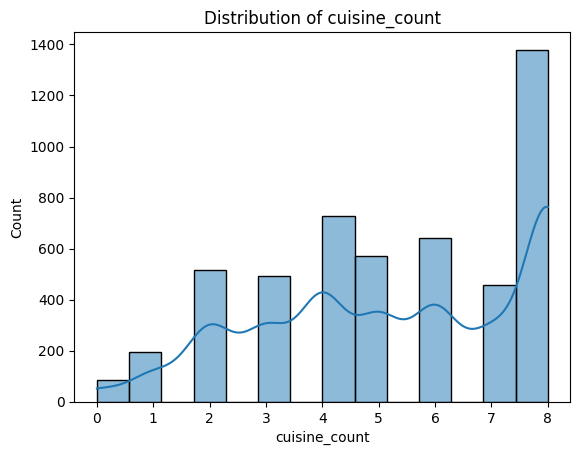

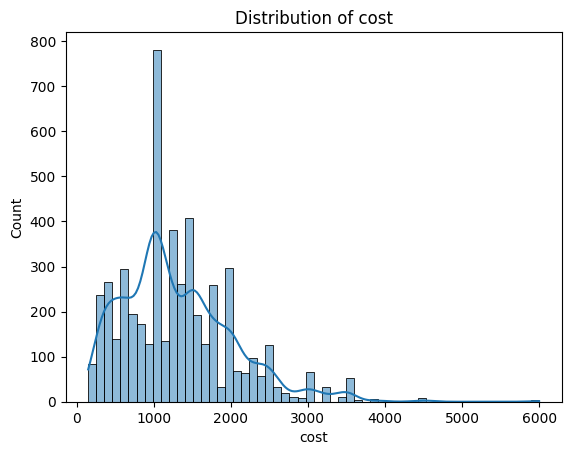

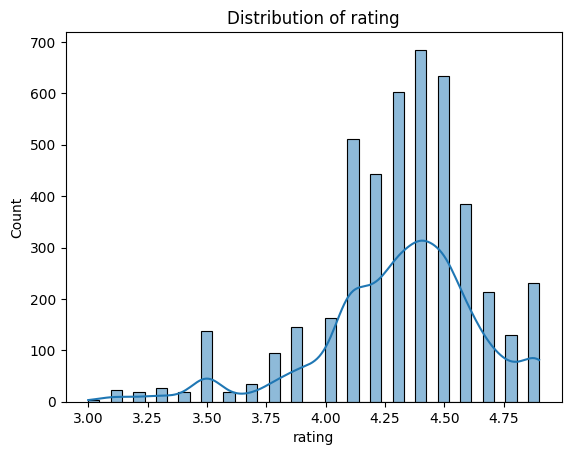

In [ ]:
for col in num_cols:
    if df[col].nunique() > 2:
        plt.figure()
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

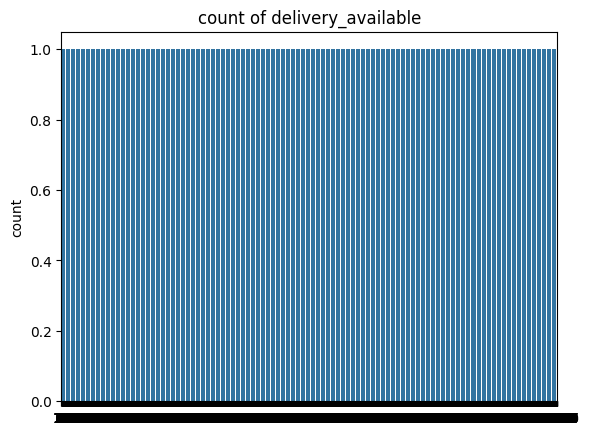

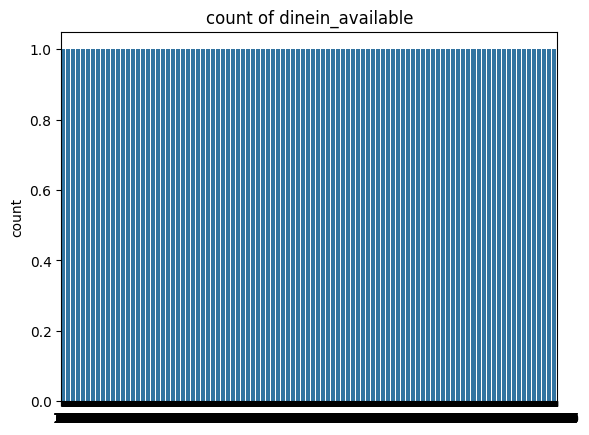

In [ ]:
for col in num_cols:
    if df[col].nunique() == 2:
        plt.figure()
        sns.countplot(df[col])
        plt.title(f"count of {col}")
        plt.show()


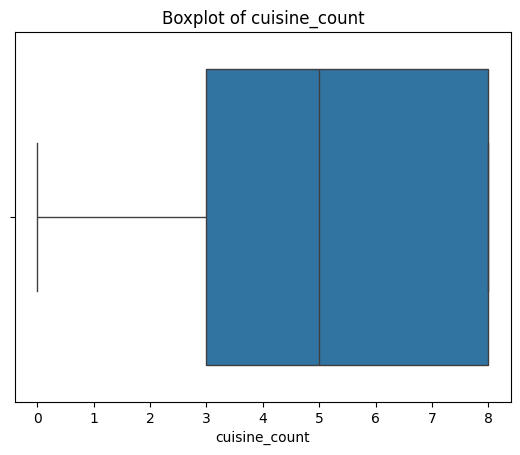

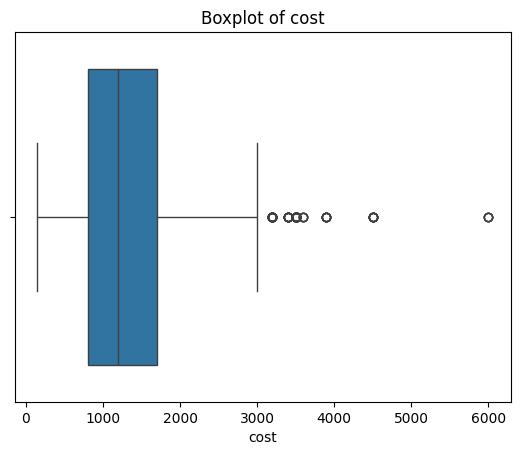

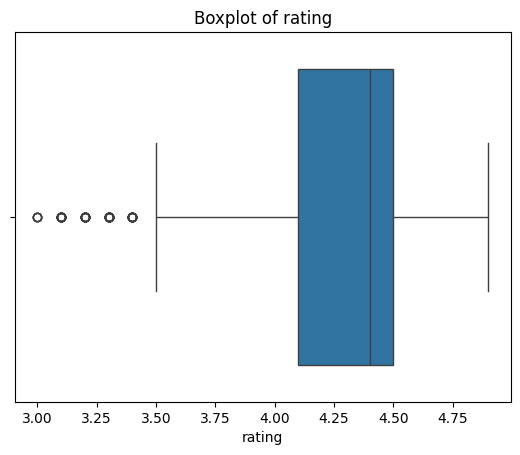

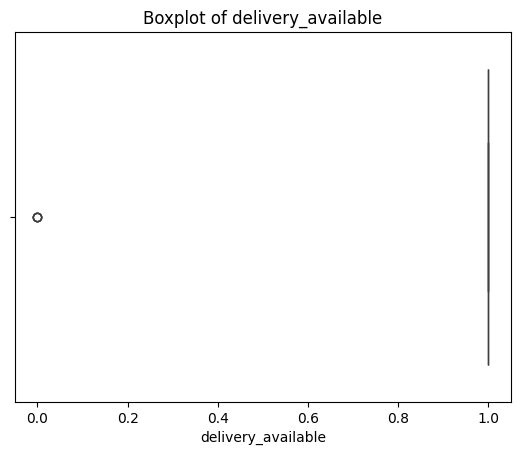

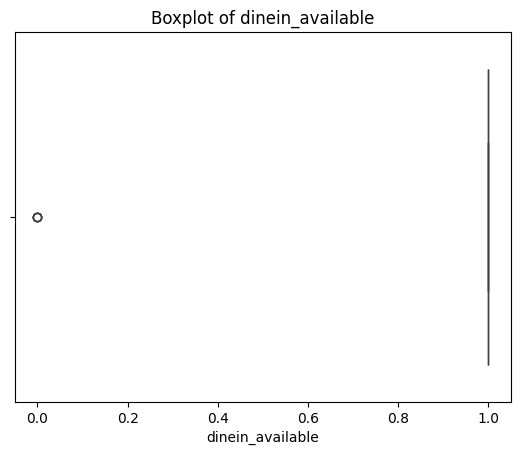

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

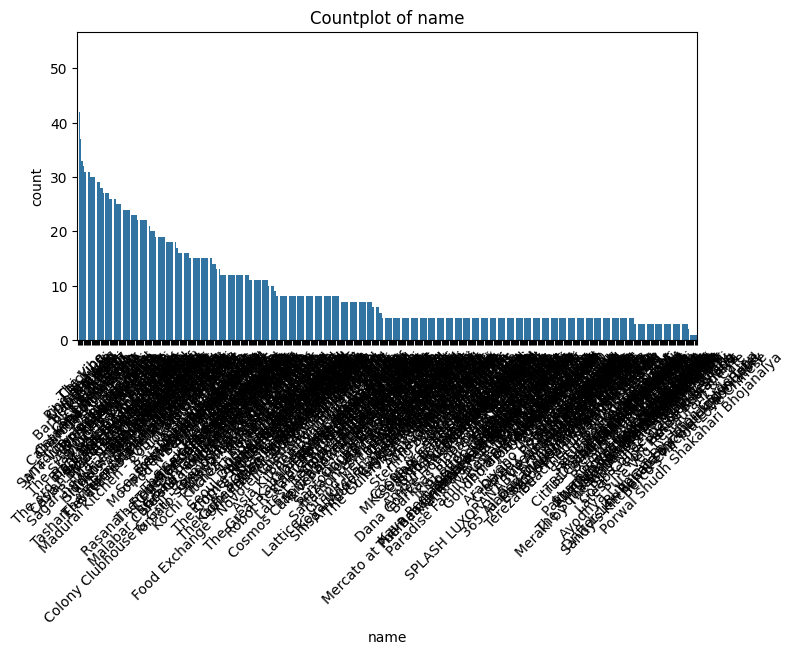

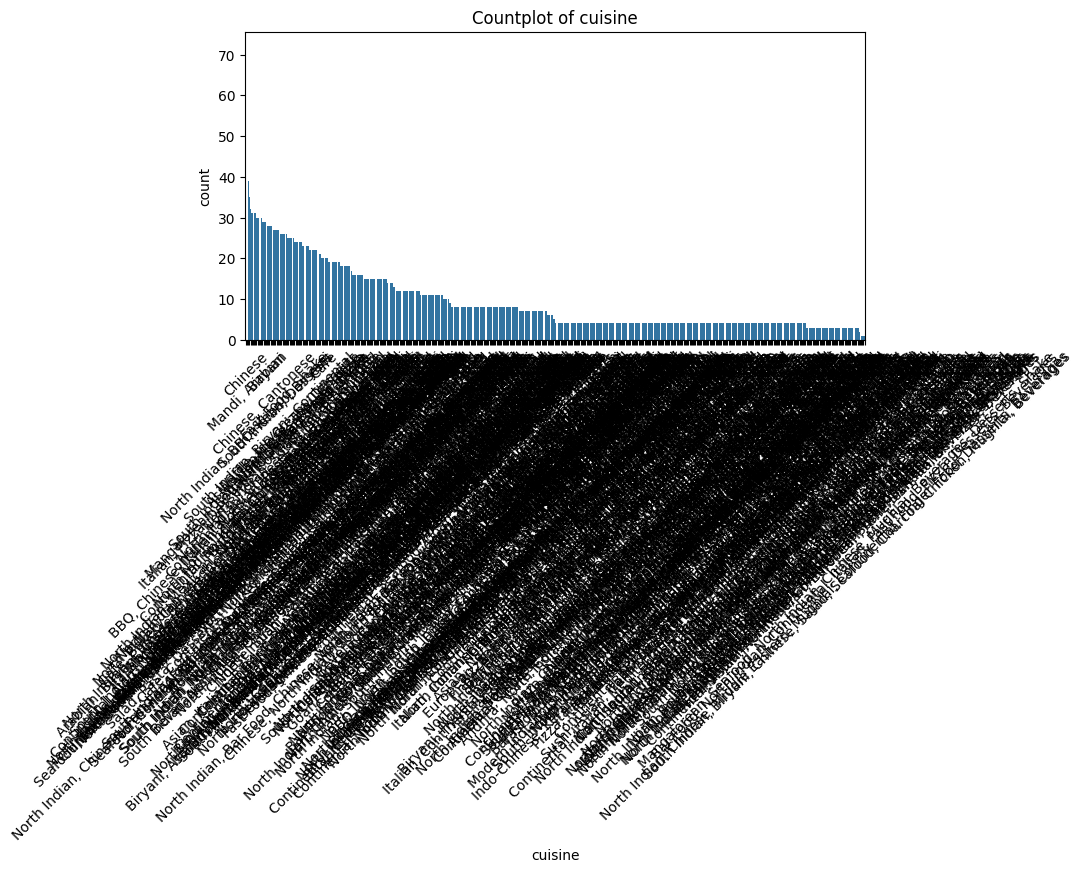

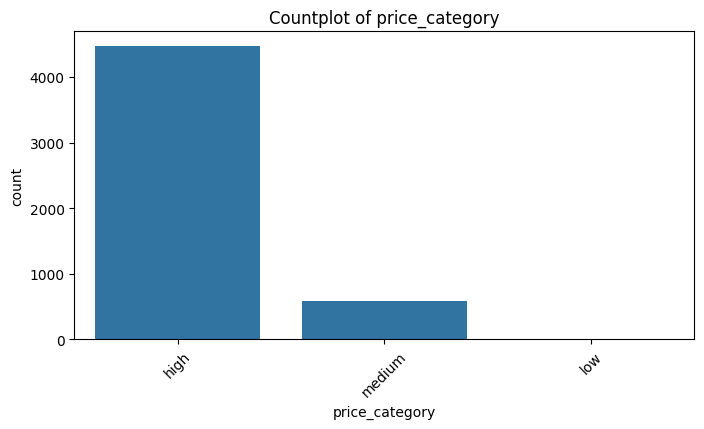

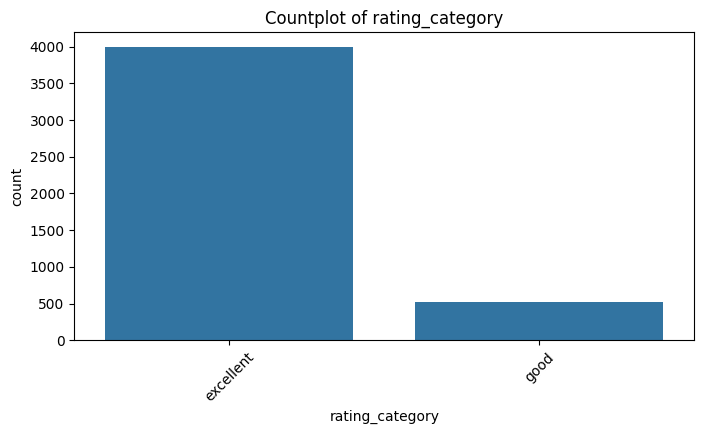

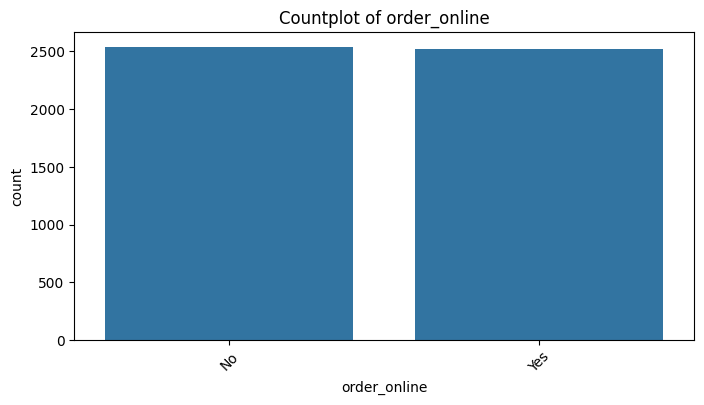

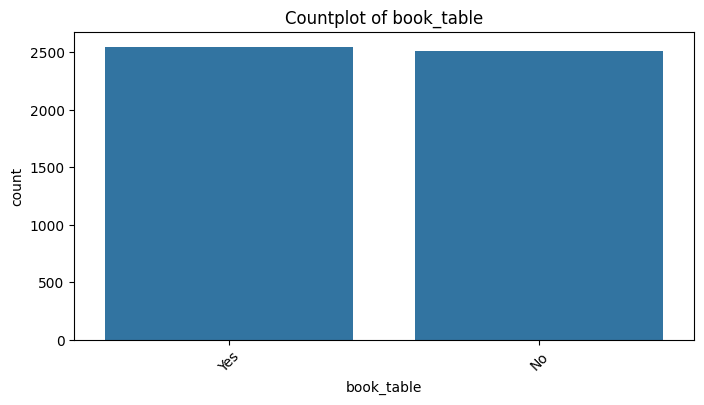

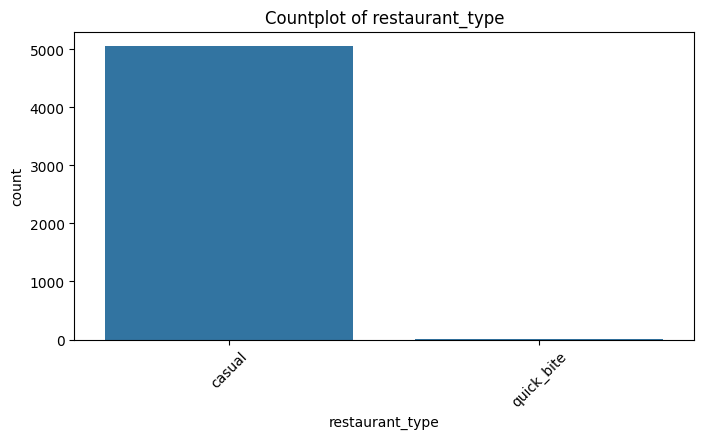

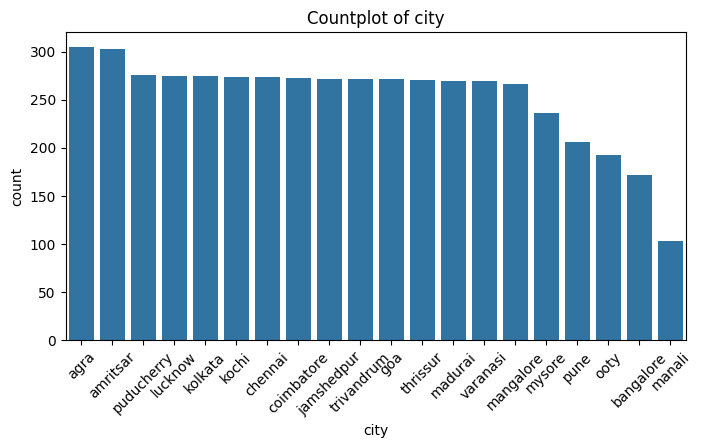

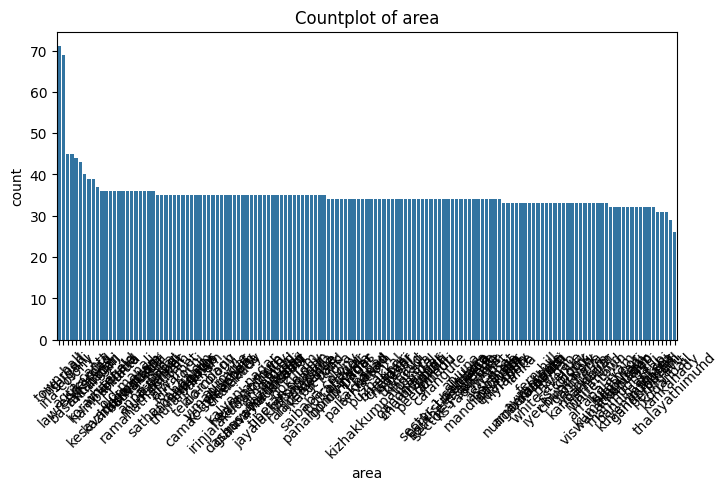

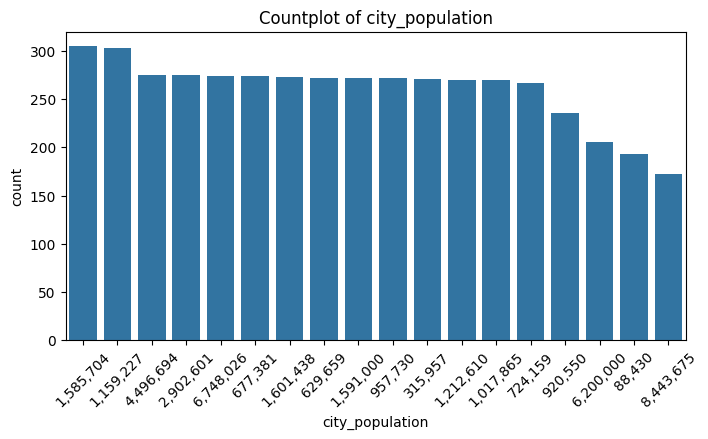

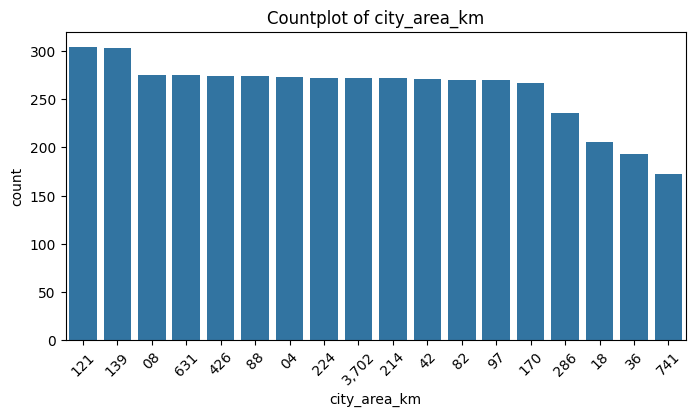

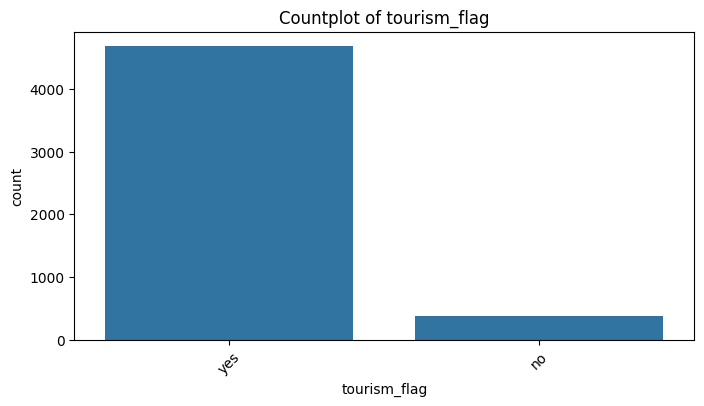

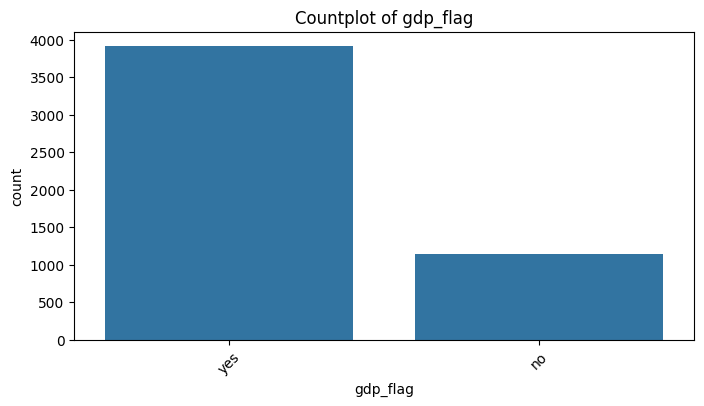

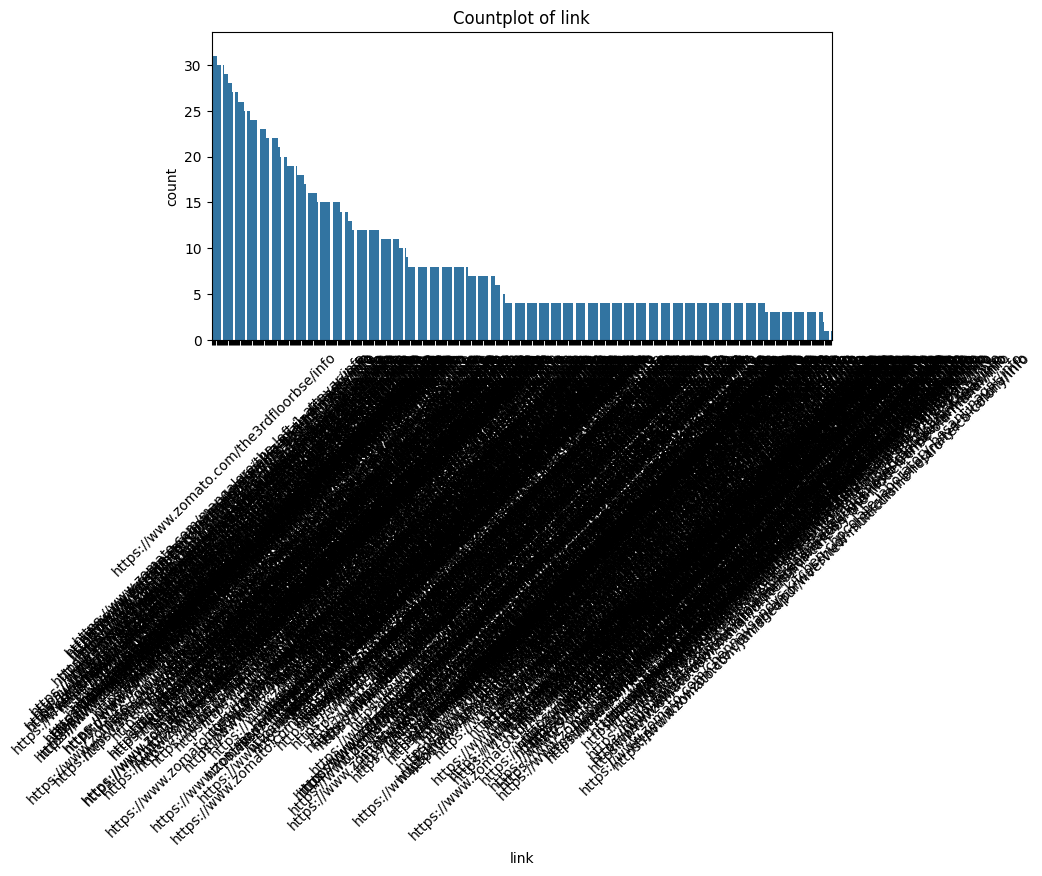

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'mg-road'),
  Text(1, 0, 'town-hall'),
  Text(2, 0, 'basant-nagar'),
  Text(3, 0, 'ina-colony'),
  Text(4, 0, 'lawrence-road'),
  Text(5, 0, 'rakabganj'),
  Text(6, 0, 'khandari'),
  Text(7, 0, 'tajganj'),
  Text(8, 0, 'agra-cantt'),
  Text(9, 0, 'sikandra')])

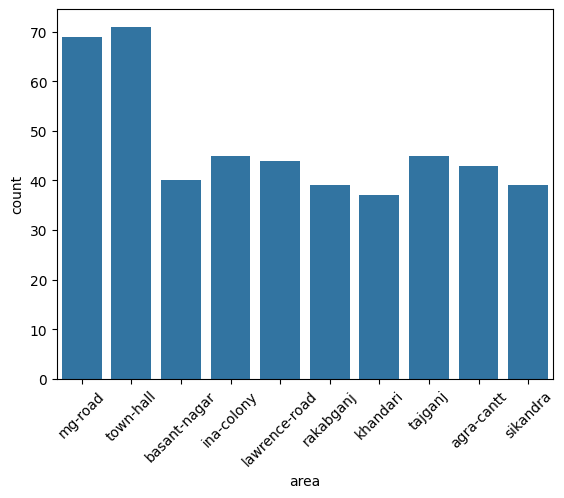

In [ ]:
top_areas = df["area"].value_counts().head(10).index
sns.countplot(x=df[df["area"].isin(top_areas)]["area"])
plt.xticks(rotation=45)


In [ ]:
df["cuisine"].value_counts().head(10)

,count
cuisine,
Chinese,72
"North Indian, BBQ, Kebab, Biryani",50
"Mandi, Arabian",39
"Arabian, Biryani, Chinese, Mandi, South Indian, North Indian, Shake, Desserts",35
"North Indian, Chinese, Mediterranean, Continental, Mexican, Modern Indian",32
"Seafood, Mangalorean, Goan, South Indian, North Indian, Chinese, Desserts, Beverages",31
"BBQ, Chinese, Italian, North Indian, Fast Food, Beverages",31
"Continental, North Indian, Asian, Pasta, French, Seafood, South Indian, Beverages",31
"North Indian, Continental, Chinese, Fast Food, Desserts, Beverages, Oriental, Kebab",31


### Bivariate Analysis

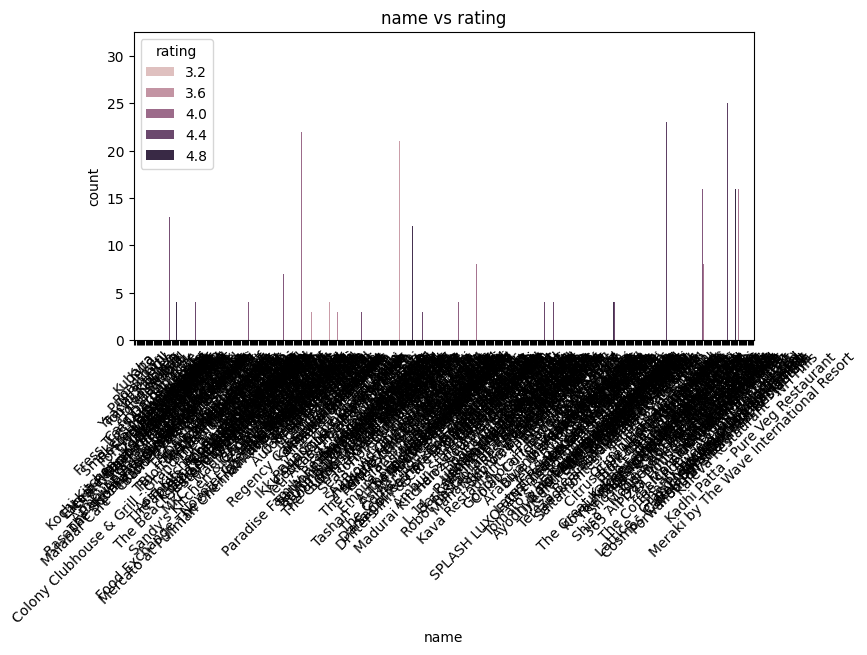

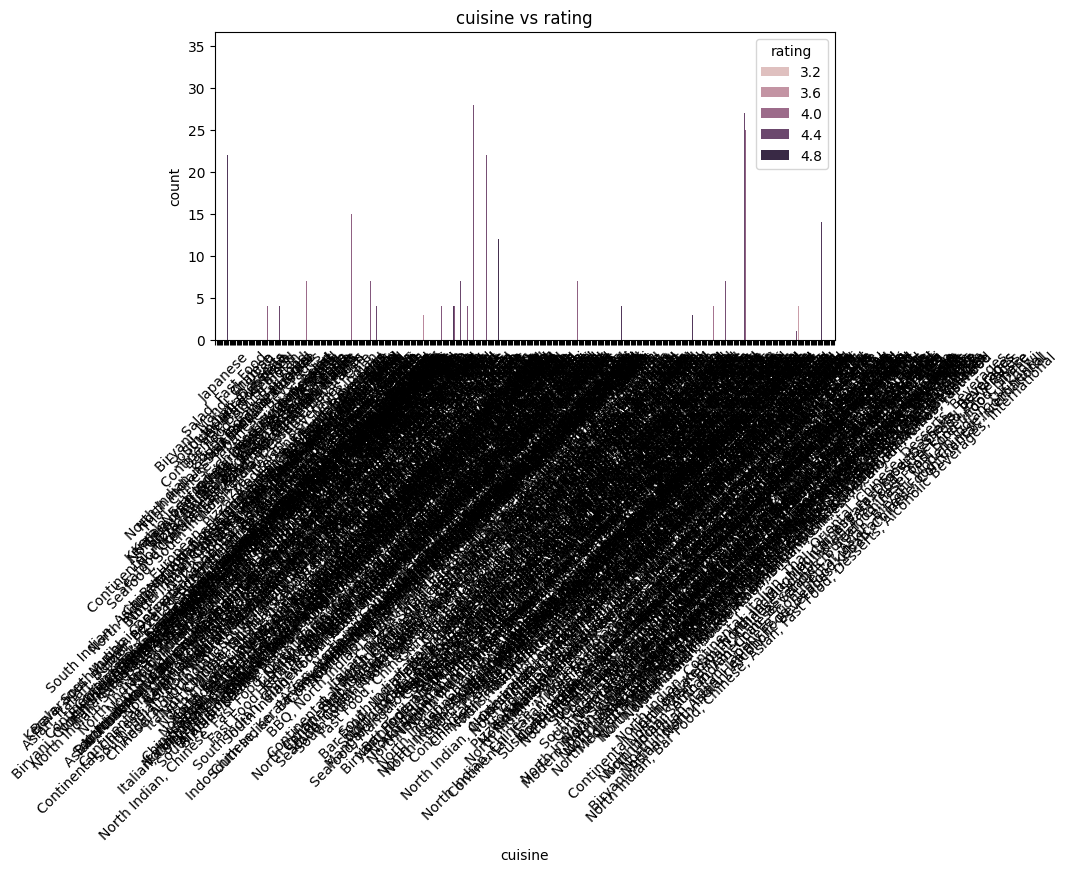

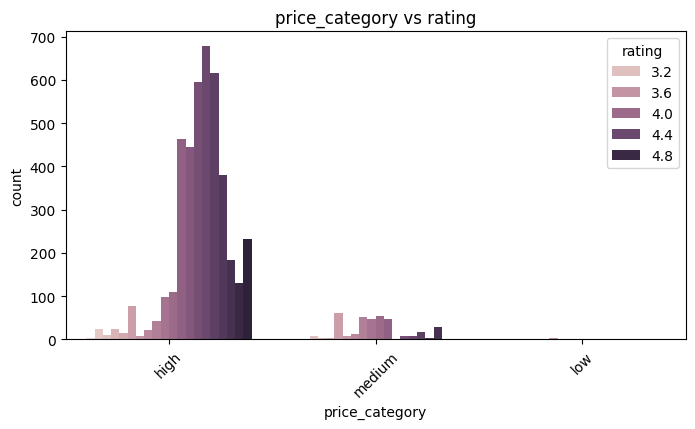

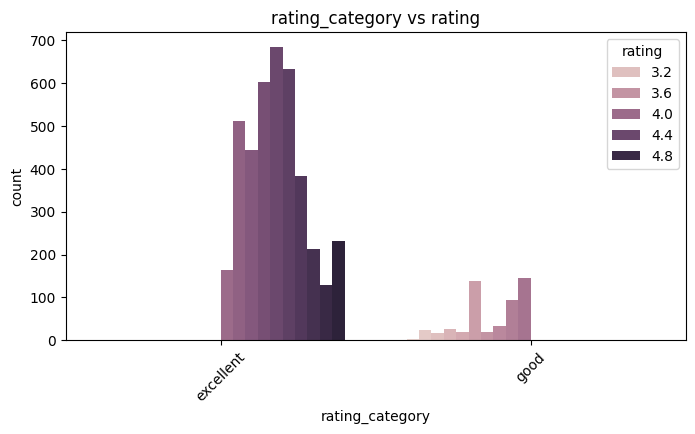

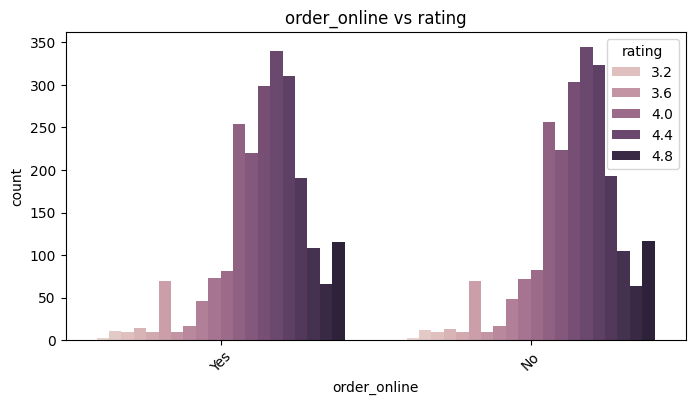

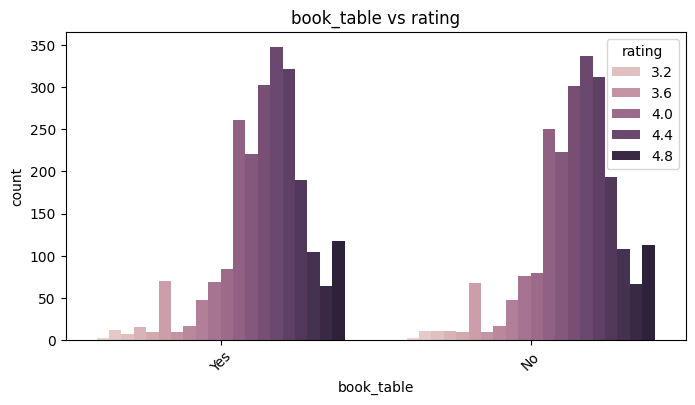

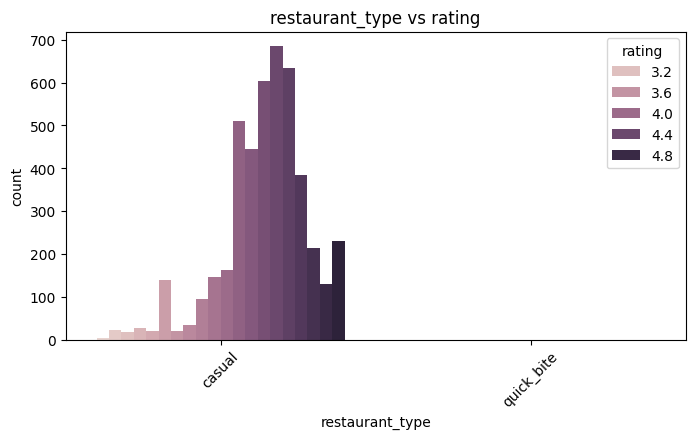

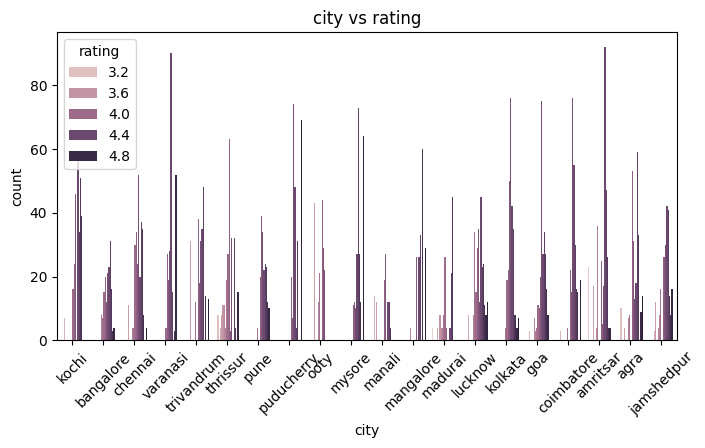

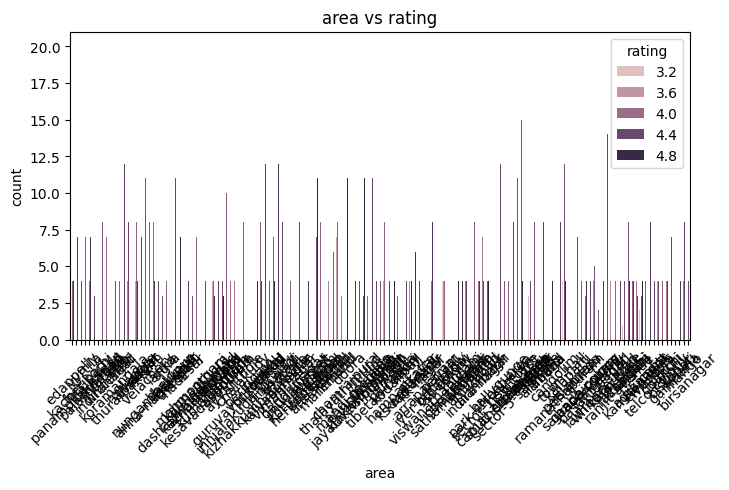

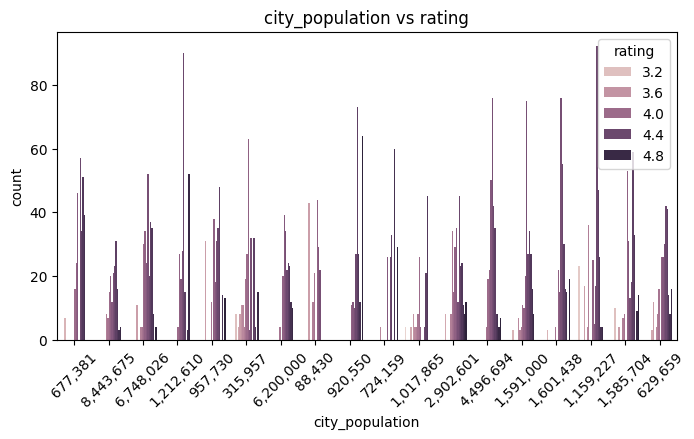

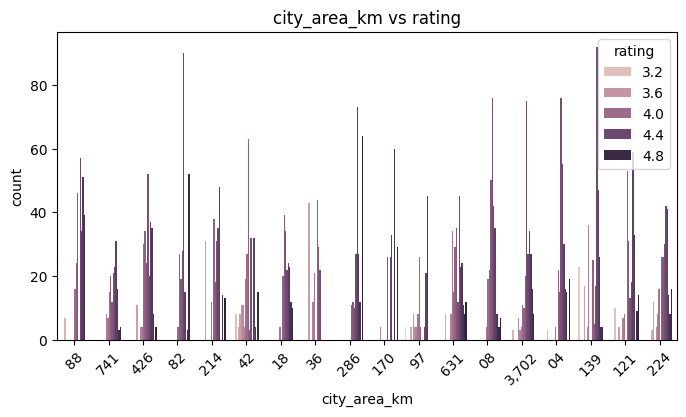

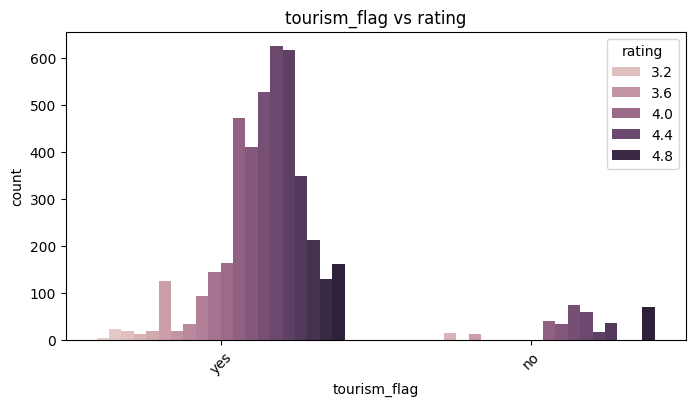

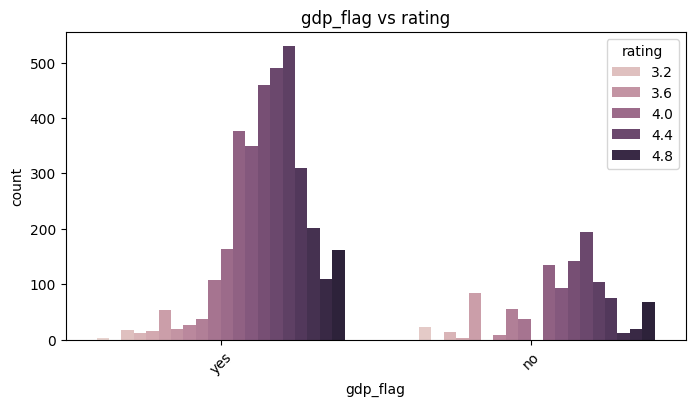

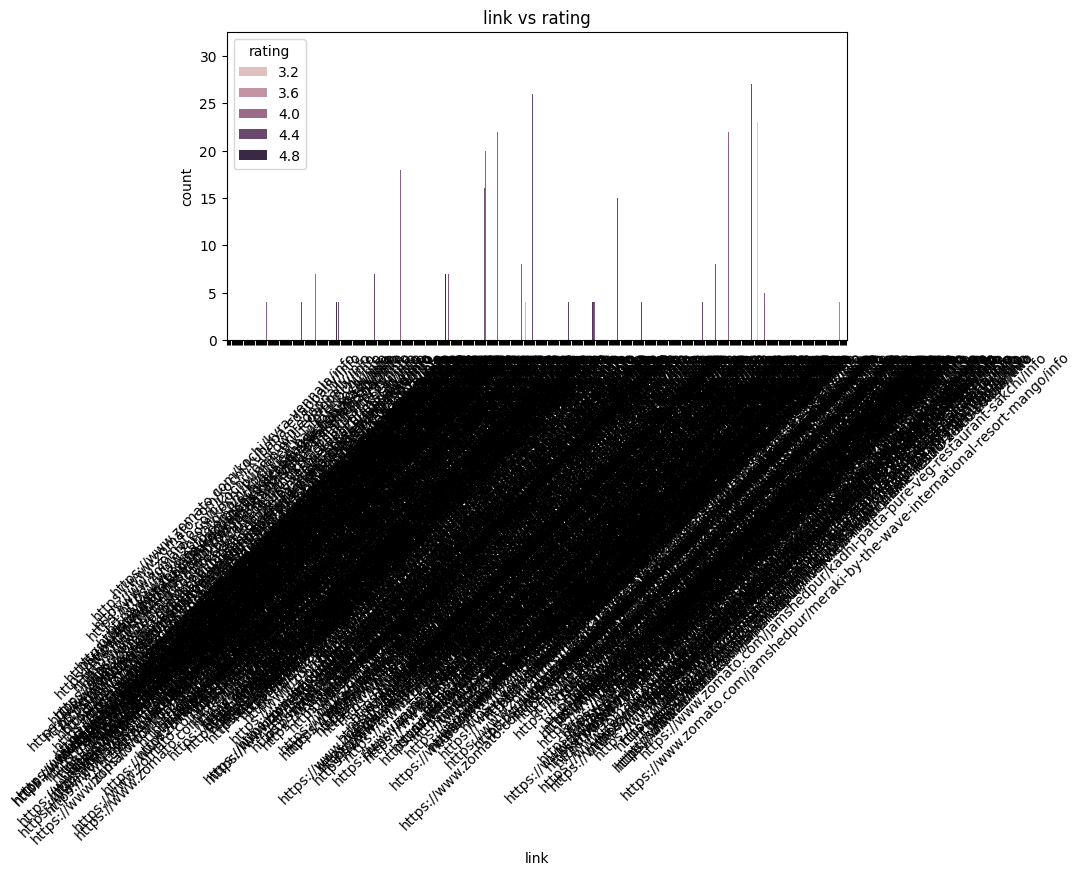

In [ ]:
target = "rating"
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col], hue=df[target])
    plt.title(f"{col} vs {target}")
    plt.xticks(rotation=45)
    plt.show()

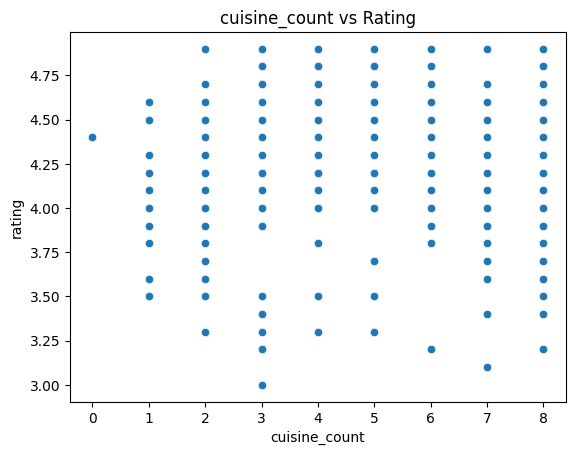

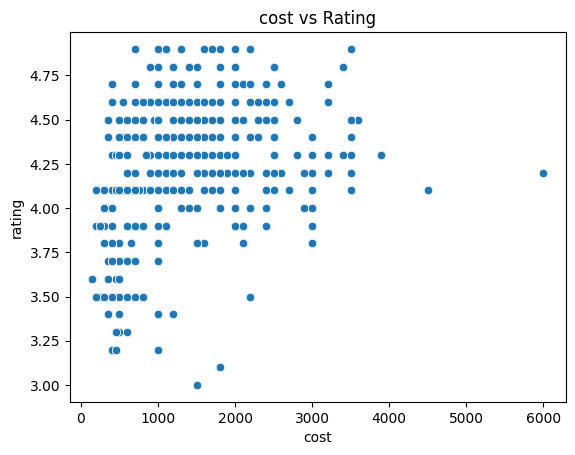

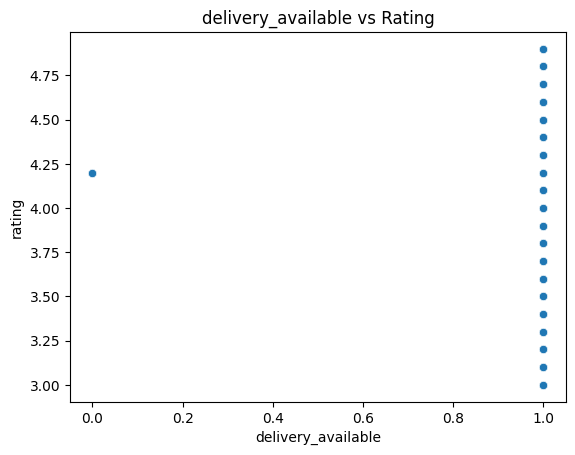

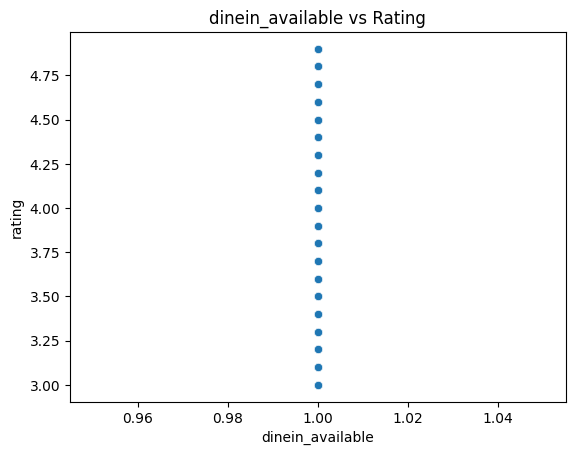

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col != "rating":
        plt.figure()
        sns.scatterplot(x=df[col], y=df["rating"])
        plt.title(f"{col} vs Rating")
        plt.show()

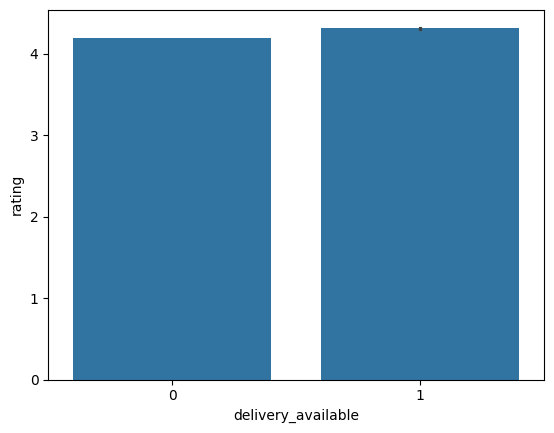

In [ ]:
sns.barplot(x=df["delivery_available"], y=df["rating"])
plt.show()

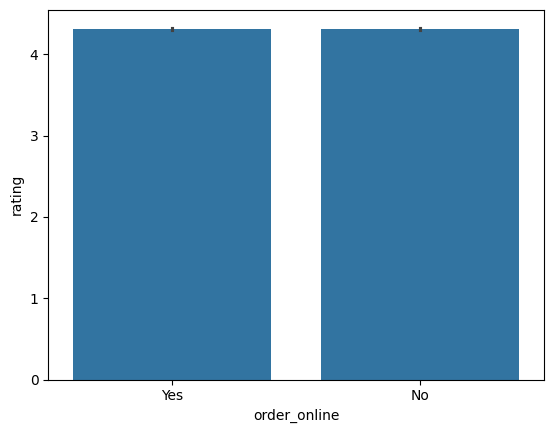

In [ ]:
sns.barplot(x=df["order_online"], y=df["rating"])
plt.show()

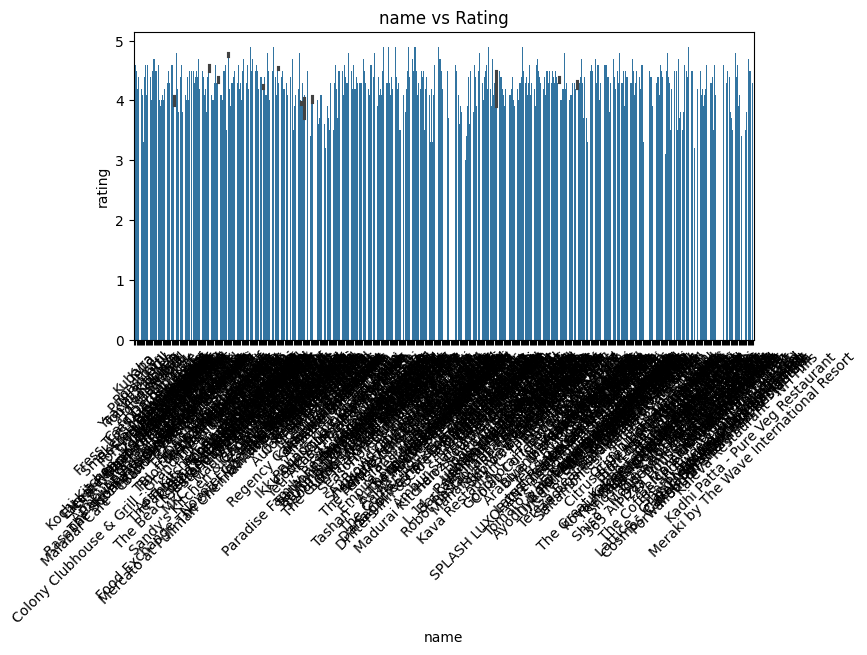

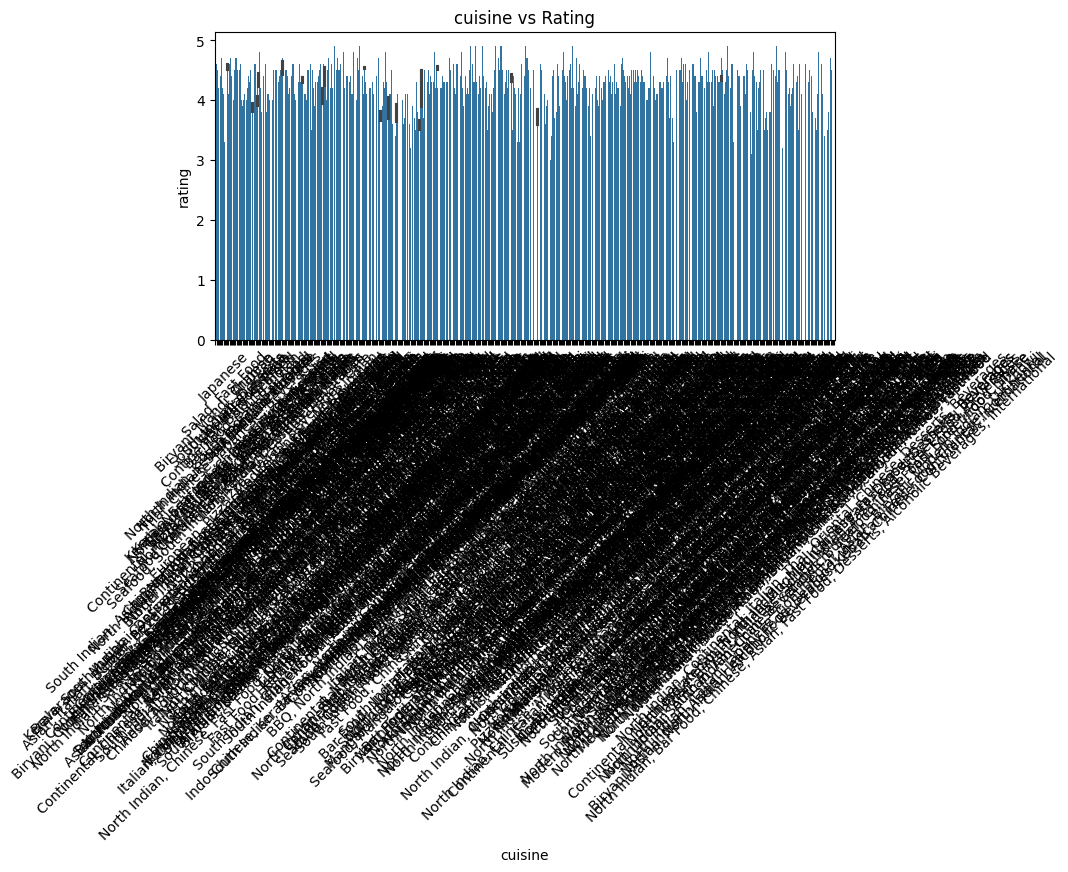

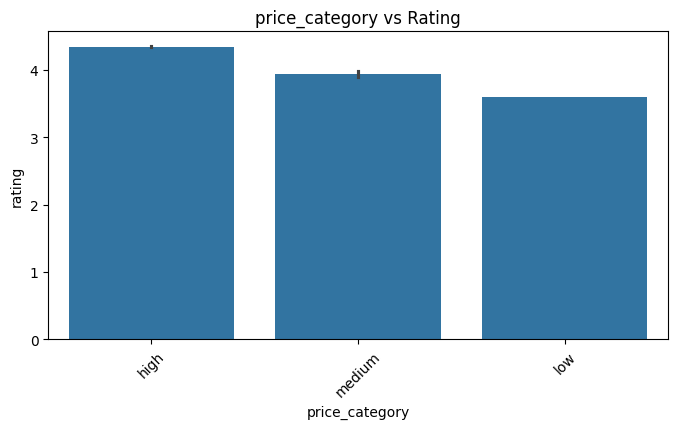

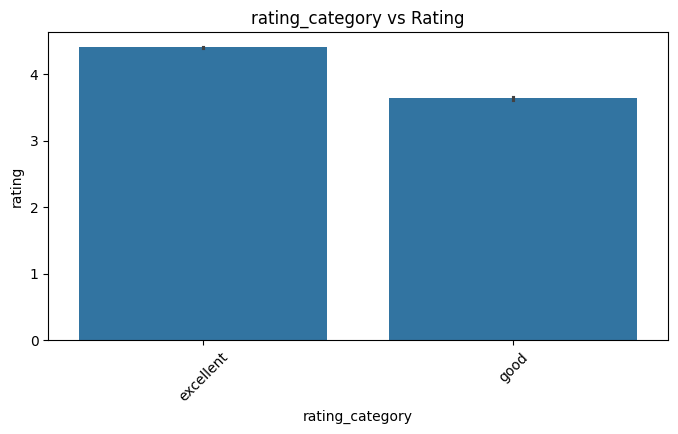

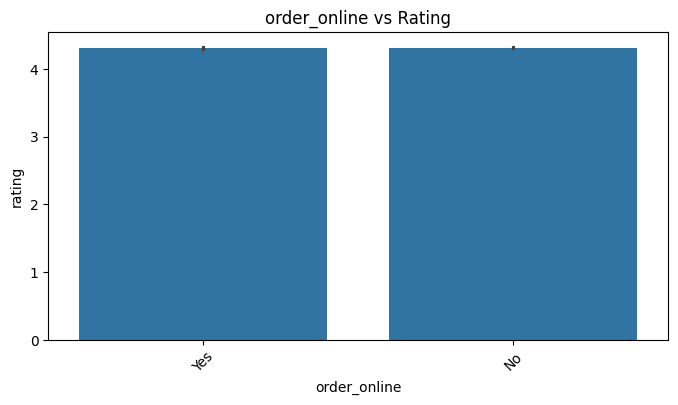

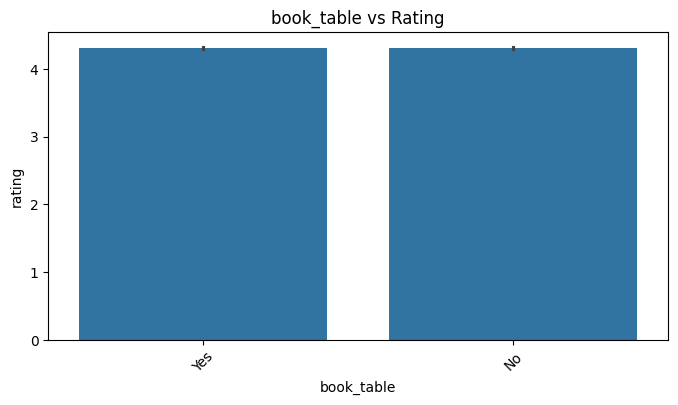

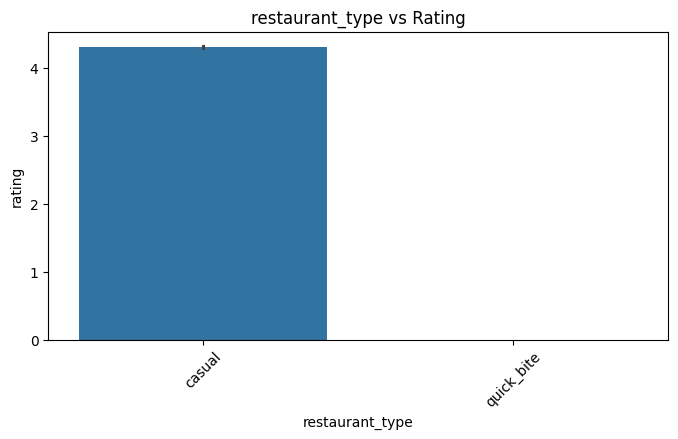

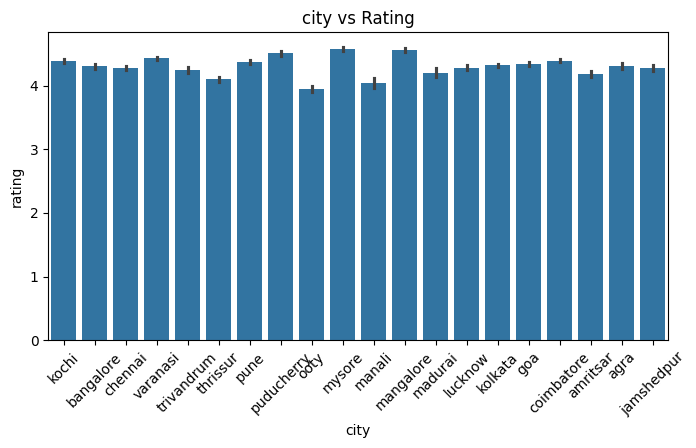

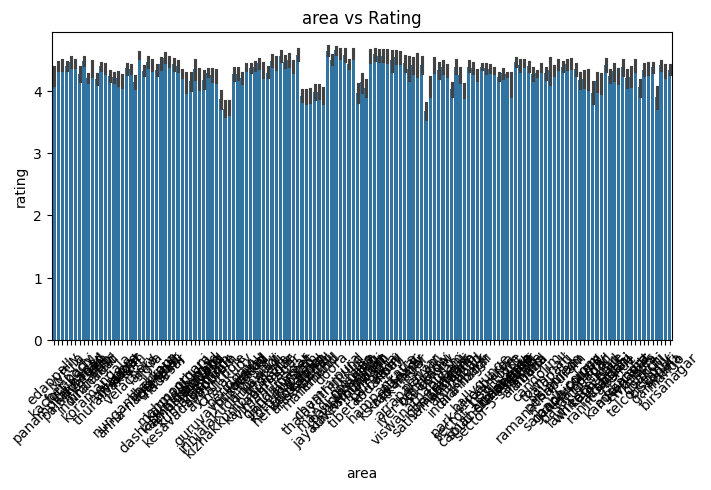

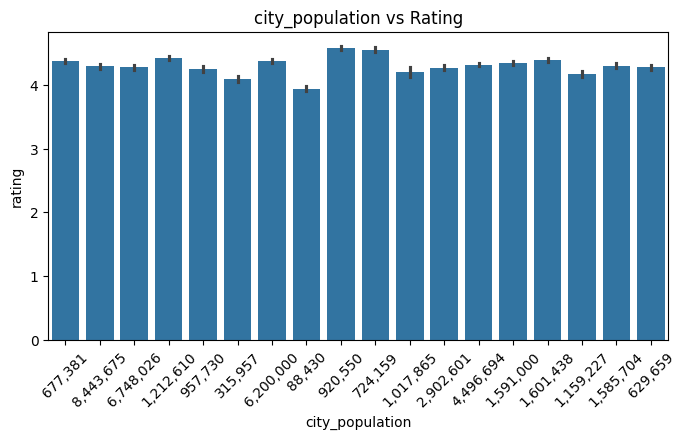

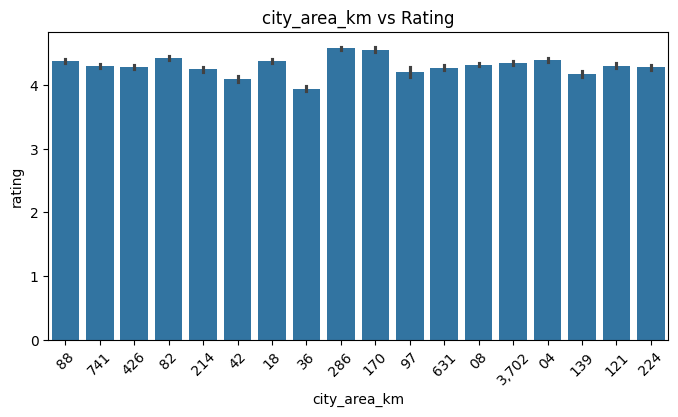

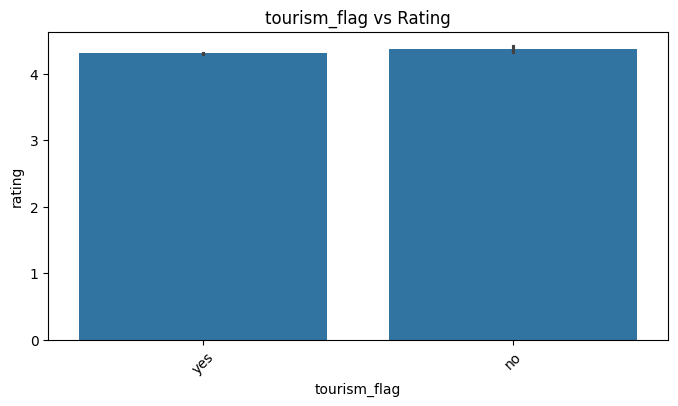

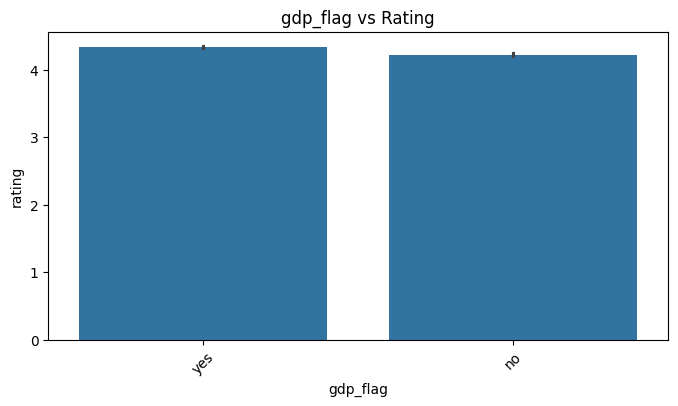

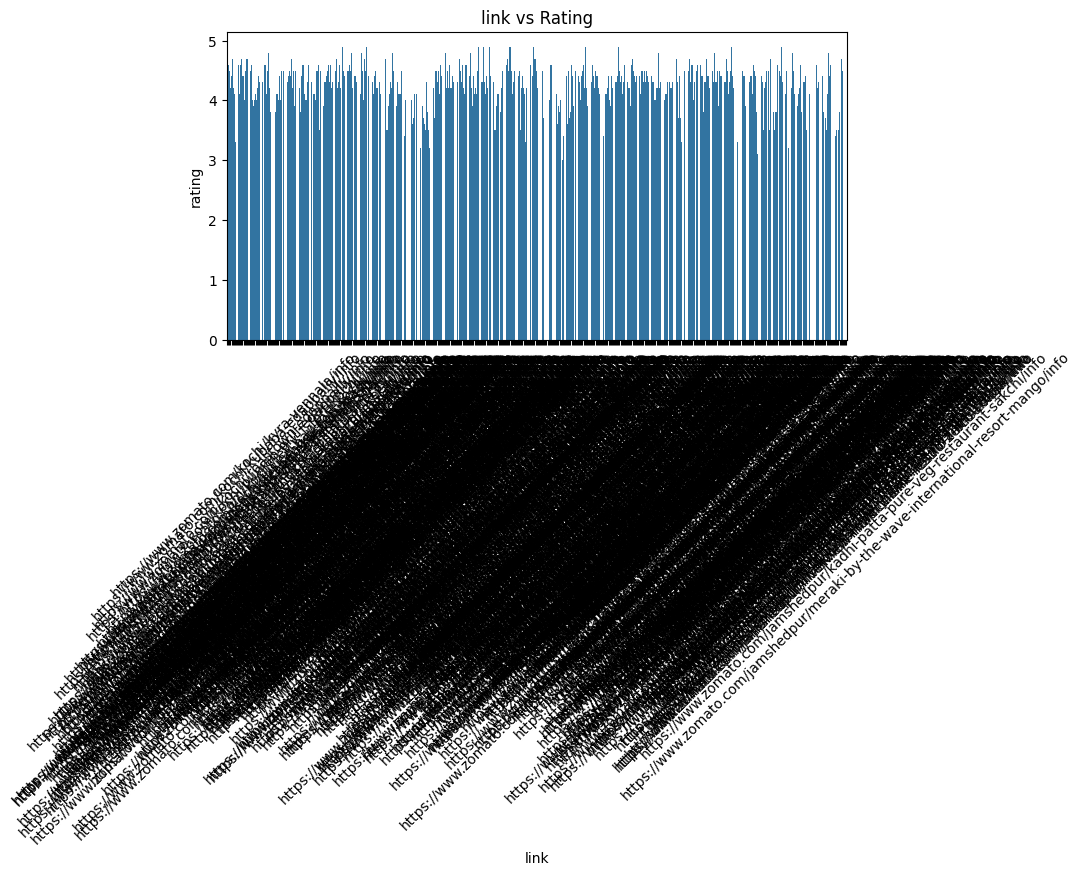

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.barplot(x=df[col], y=df["rating"])
    plt.title(f"{col} vs Rating")
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
print("\nCorrelation with target:")
corr = df.corr(numeric_only=True)
print(corr["rating"].sort_values(ascending=False))


Correlation with target:
rating                1.000000
cost                  0.230716
cuisine_count         0.177514
delivery_available    0.009936
dinein_available           NaN
Name: rating, dtype: float64


/tmp/ipykernel_3274/2953651075.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=chains,y=chains.index,palette='Set1')


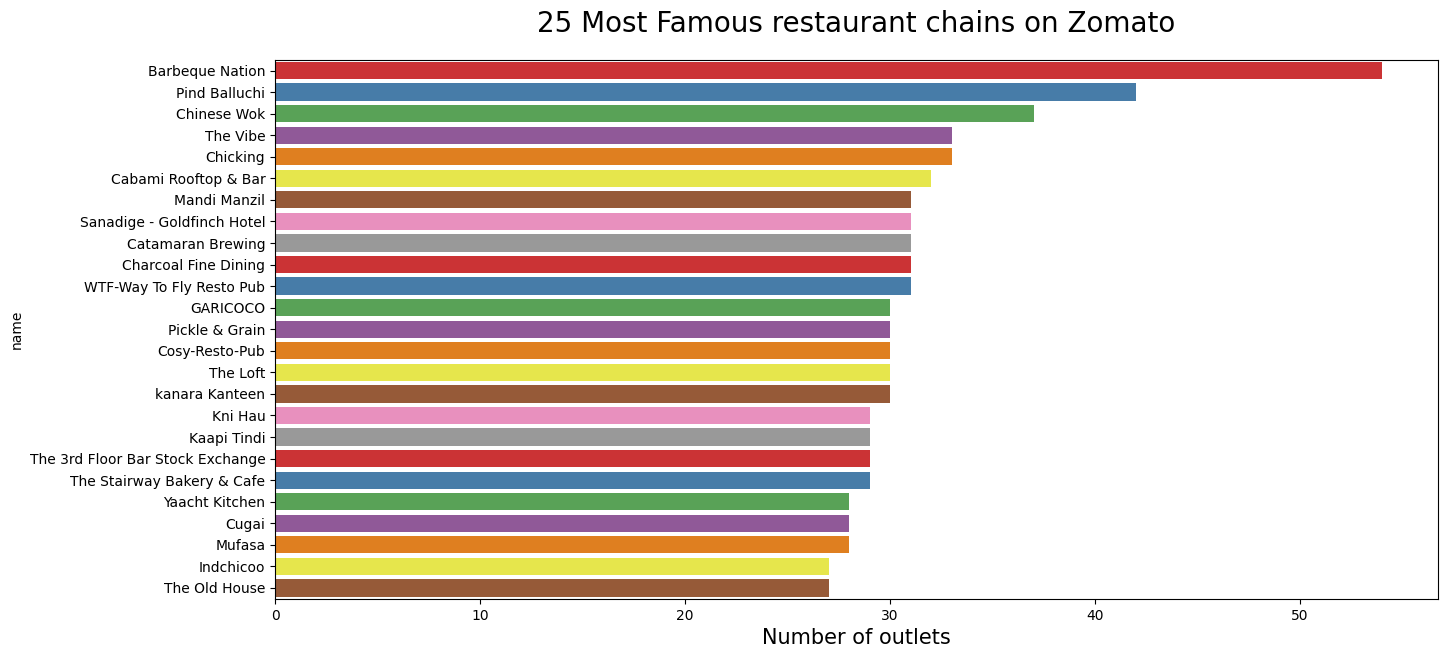

In [ ]:
# Famous restaurant
plt.figure(figsize=(15,7))
chains=df['name'].value_counts()[:25]
sns.barplot(x=chains,y=chains.index,palette='Set1')
plt.title("25 Most Famous restaurant chains on Zomato",size=20,pad=20)
plt.xlabel("Number of outlets",size=15);

/tmp/ipykernel_3274/3285814485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x,palette='Set1')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Aaina'),
  Text(1, 0, 'Anthé Restaurant'),
  Text(2, 0, 'Bulls & Bears Bistro'),
  Text(3, 0, 'Catamaran Brewing'),
  Text(4, 0, 'Kni Hau'),
  Text(5, 0, 'MIRA'),
  Text(6, 0, 'Naimat Khana'),
  Text(7, 0, 'Olterra'),
  Text(8, 0, 'Pegs & Kegs'),
  Text(9, 0, 'Sundays'),
  Text(10, 0, 'The Firangi Sutra'),
  Text(11, 0, 'The Salt Cafe Kitchen & Bar'),
  Text(12, 0, 'Villa Maya'),
  Text(13, 0, 'Calcutta Bistro'),
  Text(14, 0, 'Incanto'),
  Text(15, 0, 'Ishaara'),
  Text(16, 0, 'Malaka Spice'),
  Text(17, 0, 'Moon Brewery And Restaurant'),
  Text(18, 0, 'Pasta Street'),
  Text(19, 0, 'Pizzeria Vatika Cafe')])

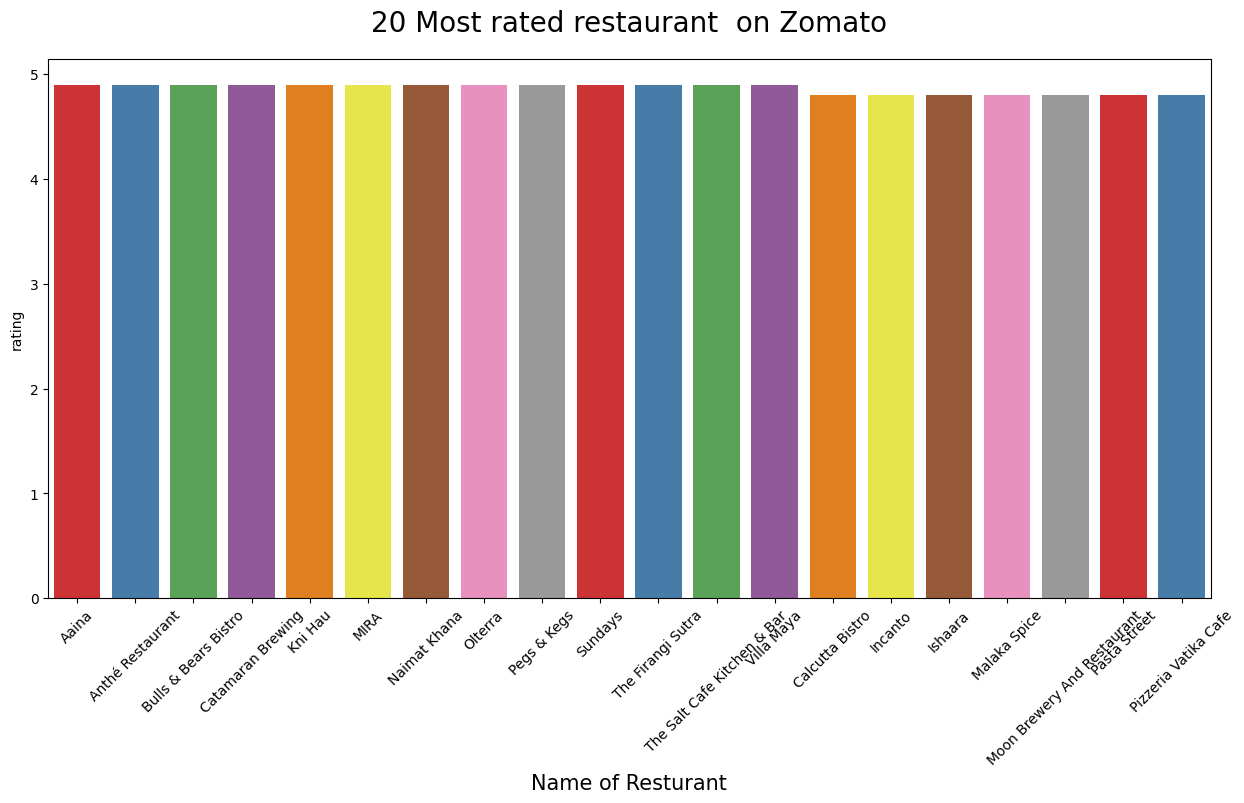

In [ ]:
# Highest Voted Restaurant
# df.groupby('name')['votes'].max().nlargest(10).plot.bar()
x = df.groupby('name')['rating'].max().nlargest(20)

plt.figure(figsize=(15,7))
sns.barplot(x,palette='Set1')
plt.title("20 Most rated restaurant  on Zomato",size=20,pad=20)
#plt.xlabel("Number of votes",size=15)
plt.xlabel("Name of Resturant",size=15)
plt.xticks(rotation=45)

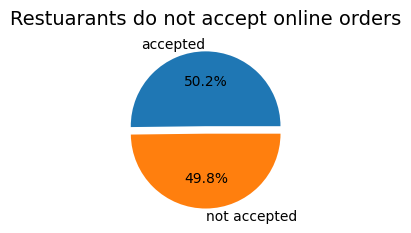

In [ ]:

plt.subplot(1,3,3)
x=df['order_online'].value_counts()
labels=['accepted','not accepted']
plt.title("Restuarants do not accept online orders", fontsize=14);
plt.pie(x,explode=[0.0,0.1],autopct='%1.1f%%', labels=labels)

plt.tight_layout()

/tmp/ipykernel_3274/3545398396.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['cost'])


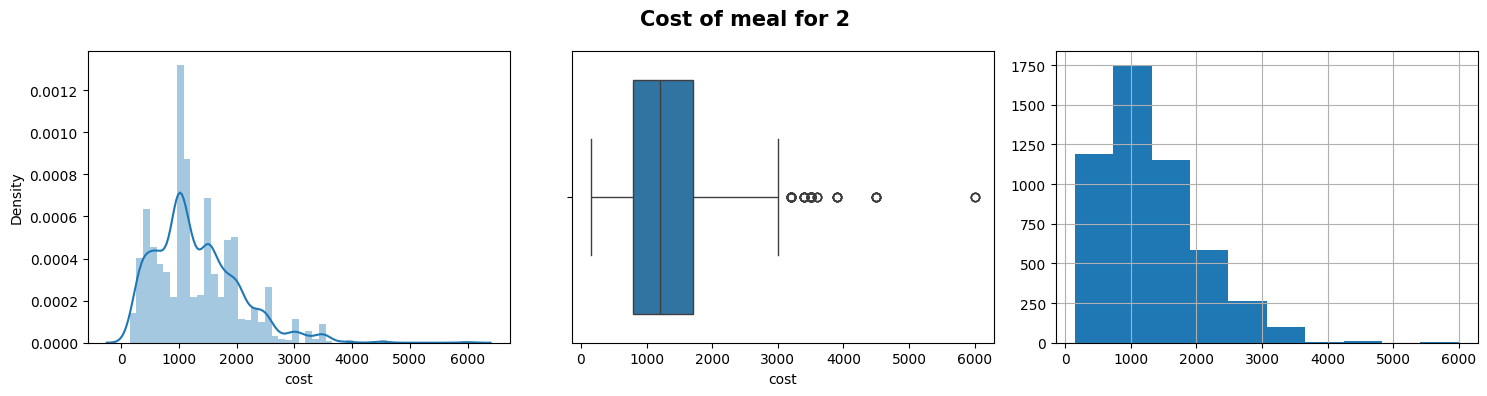

In [ ]:
plt.figure(figsize=(15,4))
plt.suptitle("Cost of meal for 2", fontweight='bold', fontsize=15)

plt.subplot(1,3,1)
sns.distplot(df['cost'])

plt.subplot(1,3,2)
sns.boxplot(x=df['cost'])

plt.subplot(1,3,3)
df['cost'].hist()

plt.tight_layout()

/tmp/ipykernel_3274/959283887.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['rating'])


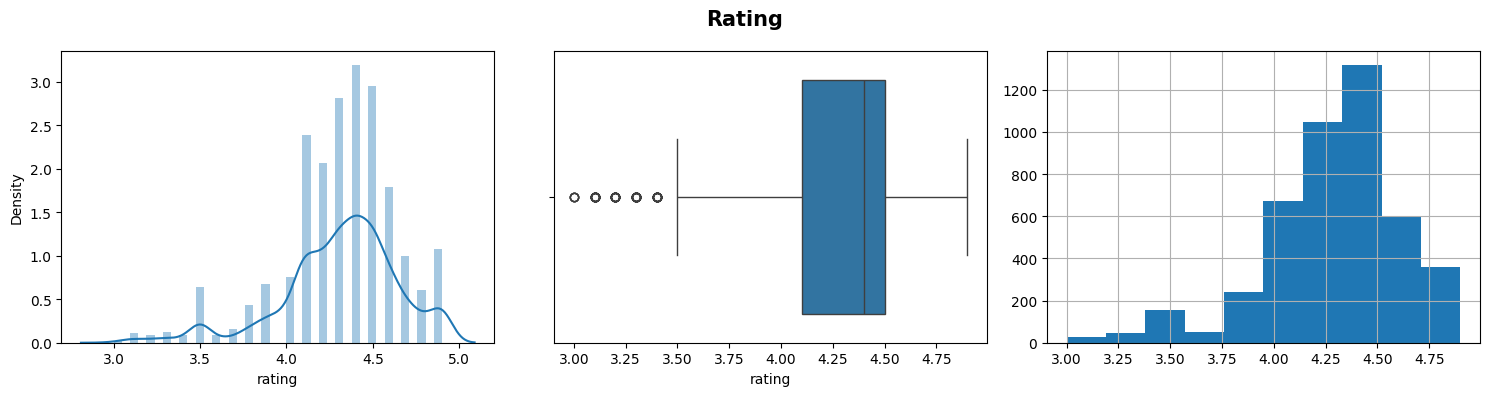

In [ ]:
plt.figure(figsize=(15,4))
plt.suptitle("Rating", fontweight='bold', fontsize=15)

plt.subplot(1,3,1)
sns.distplot(df['rating'])

plt.subplot(1,3,2)
sns.boxplot(x=df['rating'])

plt.subplot(1,3,3)
df.rating.hist()

plt.tight_layout()

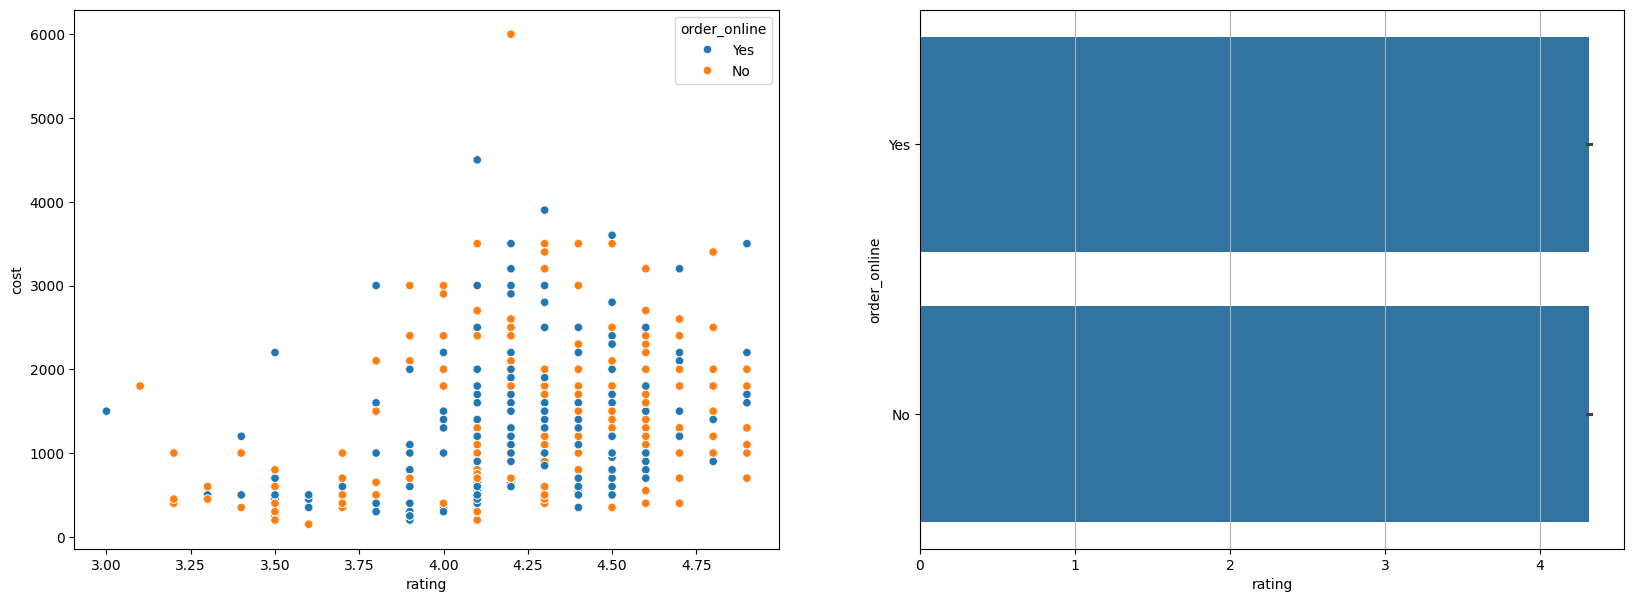

In [ ]:

plt.figure(figsize=(20,7))

plt.subplot(1,2,1)
sns.scatterplot(x="rating",y='cost',hue='order_online',data=df)

plt.subplot(1,2,2)
plt.grid(True)
sns.barplot(x='rating',y='order_online',data=df)
#sns.scatterplot(x="votes",y='online_order',data=df)

plt.show()

## Outlier Handling

In [ ]:
df['cost_log'] = np.log1p(df['cost'])

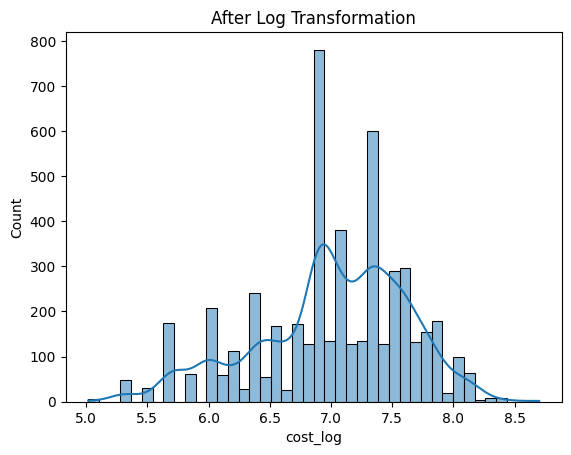

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['cost_log'], kde=True)
plt.title("After Log Transformation")
plt.show()

In [ ]:
df = df.drop(columns=['cost'])

## Null Value Filling

In [ ]:
df.isna().sum()

,0
name,0
cuisine,83
cuisine_count,0
price_category,2
rating,541
rating_category,541
order_online,0
book_table,0
delivery_available,0
dinein_available,0


In [ ]:
df["cuisine"] = df.groupby("area")["cuisine"].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)#most common cuisine per area

In [ ]:
df["cost_log"] = df.groupby(["city"])["cost_log"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
def get_price_cat(x):
    if x < 200:
        return "low"
    elif x < 800:
        return "medium"
    else:
        return "high"

df["price_category"] = df["cost_log"].apply(get_price_cat)

In [ ]:
df["rating"].fillna(df["rating"].mean(), inplace=True)

/tmp/ipykernel_3274/3701116424.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["rating"].fillna(df["rating"].mean(), inplace=True)


In [ ]:
def rating_cat(x):
    if x >= 4:
        return "excellent"
    elif x >= 3:
        return "good"
    else:
        return "poor"

df["rating_category"] = df["rating"].apply(rating_cat)

In [ ]:
#object --> float

df["city_population"] = (df["city_population"].astype(str).str.replace(",", "", regex=False))

df["city_area_km"] = (df["city_area_km"].astype(str).str.replace(",", "", regex=False))

# Convert to numeric
df["city_population"] = pd.to_numeric(df["city_population"], errors="coerce")
df["city_area_km"] = pd.to_numeric(df["city_area_km"], errors="coerce")

In [ ]:
# Manali
df.loc[df["city"] == "manali", "city_population"] = 11700
df.loc[df["city"] == "manali", "city_area_km"] = 294

# Puducherry
df.loc[df["city"] == "puducherry", "city_population"] = 941000
df.loc[df["city"] == "puducherry", "city_area_km"] = 5503

In [ ]:
df.isna().sum()

,0
name,0
cuisine,0
cuisine_count,0
price_category,0
rating,0
rating_category,0
order_online,0
book_table,0
delivery_available,0
dinein_available,0


## Remove unwanted columns for ML

In [ ]:
df_final = df.drop(columns=["name","link","rating_category","area","restaurant_type" ])

## Encoding

In [ ]:
df_final

,cuisine,cuisine_count,price_category,rating,order_online,book_table,delivery_available,dinein_available,city,city_population,city_area_km,tourism_flag,gdp_flag,cost_log
0,"Biryani, Mandi, Arabian",3,low,4.4,Yes,Yes,1,1,kochi,677381.0,88.0,yes,yes,6.908755
1,"South Indian, Asian, North Indian, Continental...",6,low,4.6,Yes,Yes,1,1,kochi,677381.0,88.0,yes,yes,7.824446
2,"Continental, Pizza, Beverages, Asian, Burger, ...",6,low,4.5,Yes,No,1,1,kochi,677381.0,88.0,yes,yes,6.398595
3,"Kerala, South Indian, Continental, Oriental, A...",8,low,4.2,Yes,No,1,1,kochi,677381.0,88.0,yes,yes,7.313887
4,"North Indian, Kebab, Biryani, Mughlai",4,low,4.4,No,Yes,1,1,kochi,677381.0,88.0,yes,yes,7.438972
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13158,"North Indian, Chinese, Fast Food, Seafood, Mug...",5,low,4.3,Yes,Yes,1,1,jamshedpur,629659.0,224.0,yes,no,6.398595
13170,"North Indian, Continental, Italian, Thai, Orie...",8,low,4.4,No,No,1,1,jamshedpur,629659.0,224.0,yes,no,7.313887
13176,"North Indian, Chinese, Fast Food, Seafood, Mug...",5,low,4.3,No,No,1,1,jamshedpur,629659.0,224.0,yes,no,6.398595
13177,"North Indian, Chinese, Continental, Sushi, Asi...",8,low,4.2,No,No,1,1,jamshedpur,629659.0,224.0,yes,no,6.552508


In [ ]:
df_final.shape

(5059, 14)

In [ ]:
df_final.dtypes

,0
cuisine,object
cuisine_count,int64
price_category,object
rating,float64
order_online,object
book_table,object
delivery_available,int64
dinein_available,int64
city,object
city_population,float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

In [ ]:
# numerical_cols = ["cuisine_count", "cost_log", "city_population", "city_area_km"]

# categorical_cols = [ "cuisine","price_category","order_online", "book_table","city","delivery_available", "dinein_available","tourism_flag", "gdp_flag"]

In [ ]:
df_final["order_online"] = df_final["order_online"].map({"Yes":1, "No":0})
df_final["book_table"] = df_final["book_table"].map({"Yes":1, "No":0})
df_final["tourism_flag"] = df_final["tourism_flag"].map({"yes":1, "no":0})
df_final["gdp_flag"] = df_final["gdp_flag"].map({"yes":1, "no":0})

In [ ]:
onehot_col = ["city"]
ordinal_cols = ["price_category"]
cuisine_col = ["cuisine"]

numerical_cols = [
    "cuisine_count",
    "cost_log",
    "city_population",
    "city_area_km",
    "order_online",
    "book_table",
    "delivery_available",
    "dinein_available",
    "tourism_flag",
    "gdp_flag"
]

price_order = [["low", "medium", "high"]]

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

class MultiLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, min_freq=30):
        self.mlb = MultiLabelBinarizer()
        self.min_freq = min_freq

    def clean_split(self, x):
        if isinstance(x, str):
            return [i.strip().lower() for i in x.split(",") if i.strip()]
        return []

    def fit(self, X, y=None):
        X_clean = X.squeeze().apply(self.clean_split)

        all_items = [item for sublist in X_clean for item in sublist]
        counts = Counter(all_items)

        self.frequent_classes = {k for k, v in counts.items() if v >= self.min_freq}

        X_filtered = X_clean.apply(
            lambda lst: [i if i in self.frequent_classes else "other" for i in lst]
        )

        self.mlb.fit(X_filtered)
        return self

    def transform(self, X):
        X_clean = X.squeeze().apply(self.clean_split)

        X_filtered = X_clean.apply(
            lambda lst: [i if i in self.frequent_classes else "other" for i in lst]
        )

        return self.mlb.transform(X_filtered)

    def get_feature_names_out(self, input_features=None):
        return self.mlb.classes_

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_col),
        ("ordinal", OrdinalEncoder(categories=price_order), ordinal_cols),
        ("num", StandardScaler(), numerical_cols),
        ("cuisine", MultiLabelEncoder(),cuisine_col)
    ]

)

In [ ]:
def build_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [ ]:
X = df_final.drop("rating", axis=1)
y = df_final["rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Selection

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR


### Linear Regression

In [ ]:
lr = LinearRegression()
pipe_lr = build_pipeline(lr)
pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)

### Decision Tree

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
pipe_dt = build_pipeline(dt)
pipe_dt.fit(X_train, y_train)

y_pred_dt = pipe_dt.predict(X_test)

### Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
pipe_rf = build_pipeline(rf)
pipe_rf.fit(X_train, y_train)

y_pred_rf = pipe_rf.predict(X_test)

###Gradient Boosting

In [ ]:
gb = GradientBoostingRegressor(random_state=42)
pipe_gb = build_pipeline(gb)
pipe_gb.fit(X_train, y_train)

y_pred_gb = pipe_gb.predict(X_test)

### XGBoosting

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
pipe_xgb = build_pipeline(xgb)
pipe_xgb.fit(X_train, y_train)

y_pred_xgb = pipe_xgb.predict(X_test)

### Ridge

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
pipe_ridge = build_pipeline(ridge)
pipe_ridge.fit(X_train, y_train)

y_pred_ridge = pipe_ridge.predict(X_test)

###Lasso

In [ ]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=0.01)
pipe_lasso = build_pipeline(lasso)
pipe_lasso.fit(X_train, y_train)

y_pred_lasso = pipe_lasso.predict(X_test)

###ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet

en = ElasticNet(alpha=0.01, l1_ratio=0.5)
pipe_en = build_pipeline(en)

pipe_en.fit(X_train, y_train)

y_pred_en = pipe_en.predict(X_test)

### KNN

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
pipe_knn = build_pipeline(knn)
pipe_knn.fit(X_train, y_train)

y_pred_knn = pipe_knn.predict(X_test)

### SVR

In [ ]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
pipe_svr = build_pipeline(svr)

pipe_svr.fit(X_train, y_train)

y_pred_svr = pipe_svr.predict(X_test)

## Evaluation

In [ ]:
# actual result --> y_test

# regression metrics: RMSE (root mean squared error) , R2 score
results = []
def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("Ridge", y_test, y_pred_ridge)
evaluate_model("Lasso", y_test, y_pred_lasso)
evaluate_model("ElasticNet", y_test, y_pred_en)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("SVR", y_test, y_pred_svr)
evaluate_model("XGBoost", y_test, y_pred_xgb)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)
results_df.reset_index(drop=True, inplace=True)

print(results_df)

               Model       MAE      RMSE  R2 Score
0      Decision Tree  0.003360  0.044474  0.981271
1            XGBoost  0.018486  0.050915  0.975453
2      Random Forest  0.012226  0.054539  0.971834
3                SVR  0.107184  0.142148  0.808663
4                KNN  0.080051  0.160079  0.757347
5  Gradient Boosting  0.143146  0.196998  0.632513
6  Linear Regression  0.197207  0.261486  0.352536
7              Ridge  0.197252  0.261541  0.352265
8         ElasticNet  0.213291  0.287323  0.218268
9              Lasso  0.221425  0.297414  0.162392


### Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
#Decision tree
param_grid = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(pipe_dt, param_grid, cv=5, scoring='r2')
grid_dt.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('onehot',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['city']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['low',
                                                                                                     'medium',
                                                                                                     'high']]),
                                                                         ['price_category']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['cuisine_count',
                                                                          'cost_log',
                                                                          'city_population',
                                                                          'city_area_km',
                                                                          'order_online',
                                                                          'book_table',
                                                                          'delivery_available',
                                                                          'dinein_available',
                                                                          'tourism_flag',
                                                                          'gdp_flag']),
                                                                        ('cuisine',
                                                                         MultiLabelEncoder(),
                                                                         ['cuisine'])])),
                                       ('model',
                                        DecisionTreeRegressor(random_state=42))]),
             param_grid={'model__max_depth': [3, 5, 10, None],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10]},
             scoring='r2')

In [ ]:
# Random forest
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(pipe_rf,param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('onehot',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['city']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['low',
                                                                                                     'medium',
                                                                                                     'high']]),
                                                                         ['price_category']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['cuisine_count',
                                                                          'cost_log',
                                                                          'city_population',
                                                                          'city_area_km',
                                                                          'order_online',
                                                                          'book_table',
                                                                          'delivery_available',
                                                                          'dinein_available',
                                                                          'tourism_flag',
                                                                          'gdp_flag']),
                                                                        ('cuisine',
                                                                         MultiLabelEncoder(),
                                                                         ['cuisine'])])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 20, None],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
#Gradient Boosting
param_grid = {
    'model__n_estimators': [100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5]
}

grid_gb = GridSearchCV(pipe_gb, param_grid, cv=5, scoring='r2')
grid_gb.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('onehot',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['city']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['low',
                                                                                                     'medium',
                                                                                                     'high']]),
                                                                         ['price_category']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['cuisine_count',
                                                                          'cost_log',
                                                                          'city_population',
                                                                          'city_area_km',
                                                                          'order_online',
                                                                          'book_table',
                                                                          'delivery_available',
                                                                          'dinein_available',
                                                                          'tourism_flag',
                                                                          'gdp_flag']),
                                                                        ('cuisine',
                                                                         MultiLabelEncoder(),
                                                                         ['cuisine'])])),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             param_grid={'model__learning_rate': [0.01, 0.1],
                         'model__max_depth': [3, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2')

In [ ]:
#Xgboosting
param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1],
    'model__colsample_bytree': [0.8, 1]
}

grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

print("Best Score:", grid_xgb.best_score_)
print("Best Params:", grid_xgb.best_params_)

Best Score: 0.9763895162681004
Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 1}


In [ ]:
#KNN
from sklearn.neighbors import KNeighborsRegressor

param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(pipe_knn, param_grid, cv=5, scoring='r2')
grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('onehot',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['city']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['low',
                                                                                                     'medium',
                                                                                                     'high']]),
                                                                         ['price_category']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['cuisine_count',
                                                                          'cost_log',
                                                                          'city_population',
                                                                          'city_area_km',
                                                                          'order_online',
                                                                          'book_table',
                                                                          'delivery_available',
                                                                          'dinein_available',
                                                                          'tourism_flag',
                                                                          'gdp_flag']),
                                                                        ('cuisine',
                                                                         MultiLabelEncoder(),
                                                                         ['cuisine'])])),
                                       ('model', KNeighborsRegressor())]),
             param_grid={'model__n_neighbors': [3, 5, 7, 9],
                         'model__weights': ['uniform', 'distance']},
             scoring='r2')

In [ ]:
#SVR
from sklearn.svm import SVR

param_grid = {
    'model__C': [0.1, 1, 10],
    'model__epsilon': [0.01, 0.1, 0.5],
    'model__kernel': ['rbf']
}

grid_svr = GridSearchCV(pipe_svr,param_grid, cv=5, scoring='r2')
grid_svr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('onehot',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['city']),
                                                                        ('ordinal',
                                                                         OrdinalEncoder(categories=[['low',
                                                                                                     'medium',
                                                                                                     'high']]),
                                                                         ['price_category']),
                                                                        ('num',
                                                                         StandardScaler(),
                                                                         ['cuisine_count',
                                                                          'cost_log',
                                                                          'city_population',
                                                                          'city_area_km',
                                                                          'order_online',
                                                                          'book_table',
                                                                          'delivery_available',
                                                                          'dinein_available',
                                                                          'tourism_flag',
                                                                          'gdp_flag']),
                                                                        ('cuisine',
                                                                         MultiLabelEncoder(),
                                                                         ['cuisine'])])),
                                       ('model', SVR())]),
             param_grid={'model__C': [0.1, 1, 10],
                         'model__epsilon': [0.01, 0.1, 0.5],
                         'model__kernel': ['rbf']},
             scoring='r2')

In [ ]:
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
0.9667171455645924


In [ ]:
best_dt = grid_dt.best_estimator_
best_rf = grid_rf.best_estimator_
best_gb = grid_gb.best_estimator_
best_xgb = grid_xgb.best_estimator_
best_knn = grid_knn.best_estimator_
best_svr = grid_svr.best_estimator_

In [ ]:
y_pred_dt_tuned = best_dt.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)
y_pred_gb_tuned = best_gb.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_pred_knn_tuned = best_knn.predict(X_test)
y_pred_svr_tuned = best_svr.predict(X_test)

In [ ]:
tuned_results = []

def evaluate_tuned(name, y_test, y_pred):
    tuned_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    })


evaluate_tuned("Decision Tree Tuned", y_test, y_pred_dt_tuned)
evaluate_tuned("Random Forest Tuned", y_test, y_pred_rf_tuned)
evaluate_tuned("Gradient Boosting Tuned", y_test, y_pred_gb_tuned)
evaluate_tuned("XGBoost Tuned", y_test, y_pred_xgb_tuned)

evaluate_tuned("KNN Tuned", y_test, y_pred_knn_tuned)
evaluate_tuned("SVR Tuned", y_test, y_pred_svr_tuned)

In [ ]:
result_tuned_df = pd.DataFrame(tuned_results)
result_tuned_df = result_tuned_df.sort_values(by="R2 Score", ascending=False)
result_tuned_df.reset_index(drop=True, inplace=True)

print(result_tuned_df)

                     Model       MAE      RMSE  R2 Score
0      Decision Tree Tuned  0.003360  0.044474  0.981271
1            XGBoost Tuned  0.010769  0.046514  0.979513
2      Random Forest Tuned  0.011992  0.053873  0.972517
3                SVR Tuned  0.026513  0.071187  0.952013
4  Gradient Boosting Tuned  0.051334  0.088465  0.925893
5                KNN Tuned  0.051471  0.135914  0.825077


In [ ]:
comparison_df = pd.concat([results_df, result_tuned_df])
print(comparison_df)

                     Model       MAE      RMSE  R2 Score
0            Decision Tree  0.003360  0.044474  0.981271
1                  XGBoost  0.018486  0.050915  0.975453
2            Random Forest  0.012226  0.054539  0.971834
3                      SVR  0.107184  0.142148  0.808663
4                      KNN  0.080051  0.160079  0.757347
5        Gradient Boosting  0.143146  0.196998  0.632513
6        Linear Regression  0.197207  0.261486  0.352536
7                    Ridge  0.197252  0.261541  0.352265
8               ElasticNet  0.213291  0.287323  0.218268
9                    Lasso  0.221425  0.297414  0.162392
0      Decision Tree Tuned  0.003360  0.044474  0.981271
1            XGBoost Tuned  0.010769  0.046514  0.979513
2      Random Forest Tuned  0.011992  0.053873  0.972517
3                SVR Tuned  0.026513  0.071187  0.952013
4  Gradient Boosting Tuned  0.051334  0.088465  0.925893
5                KNN Tuned  0.051471  0.135914  0.825077


In [ ]:
print("Train:", grid_xgb.best_estimator_.score(X_train, y_train))
print("Test :", grid_xgb.best_estimator_.score(X_test, y_test))

Train: 0.9951483051121336
Test : 0.9795492550602068


In [ ]:
print("Train:", grid_dt.best_estimator_.score(X_train, y_train))
print("Test :", grid_dt.best_estimator_.score(X_test, y_test))

Train: 0.9953816883843841
Test : 0.9812705800306436


In [ ]:
print("DT:", grid_dt.best_score_)
print("XGB:", grid_xgb.best_score_)

DT: 0.9661258632204903
XGB: 0.9750621767375746


In [ ]:
final_model = grid_xgb.best_estimator_

In [ ]:
import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(final_model, f)

In [ ]:
import sklearn
print(sklearn.__version__)

1.6.1


### important features

In [ ]:
# print(X.columns)

In [ ]:
best_model = grid_dt.best_estimator_

In [ ]:
model = best_model.named_steps["model"]

In [ ]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

In [ ]:
import pandas as pd

importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(feat_imp.head(20))

                  feature  importance
22          num__cost_log    0.208132
23   num__city_population    0.125865
30          num__gdp_flag    0.066237
21     num__cuisine_count    0.050631
0       onehot__city_agra    0.030439
78         cuisine__shake    0.026440
80  cuisine__south indian    0.026268
41          cuisine__cafe    0.023220
39       cuisine__biryani    0.021665
37           cuisine__bbq    0.021596
44   cuisine__continental    0.020997
38     cuisine__beverages    0.020891
1   onehot__city_amritsar    0.020066
42       cuisine__chinese    0.018793
24      num__city_area_km    0.018105
68       cuisine__mughlai    0.017611
61         cuisine__mandi    0.017445
40        cuisine__burger    0.017290
34         cuisine__asian    0.014748
72         cuisine__pasta    0.013224


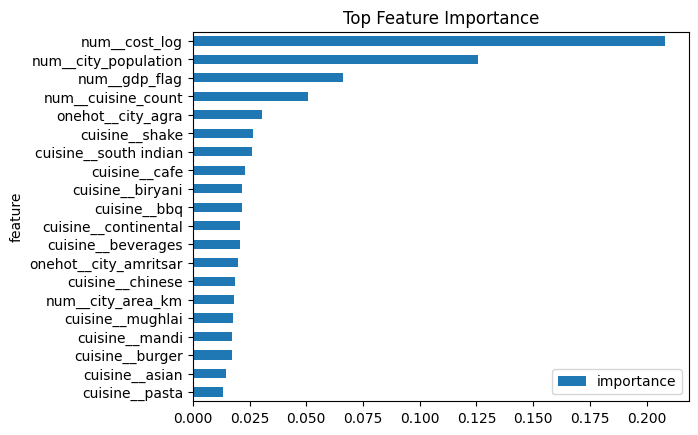

In [ ]:
import matplotlib.pyplot as plt

feat_imp.head(20).plot(
    x="feature",
    y="importance",
    kind="barh"
)

plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()